In [1]:
import pandas as pd
df = pd.read_csv('C:/Users/adith/spotify_analytics/data/cleaned/Cleaned_Spotify_2024_Global_Streaming_Data.csv')
df.head()

,Country,Artist,Album,Genre,Release Year,Monthly Listeners (Millions),Total Streams (Millions),Total Hours Streamed (Millions),Avg Stream Duration (Min),Platform Type,Streams Last 30 Days (Millions),Skip Rate (%)
0,Germany,Taylor Swift,1989 (Taylor's Version),K-pop,2020,23.10,3695.53,14240.35,4.28,Free,118.51,2.24
1,Brazil,The Weeknd,After Hours,R&B,2023,60.60,2828.16,11120.44,3.90,Premium,44.87,23.98
2,United States,Post Malone,Austin,Reggaeton,2019,42.84,1425.46,4177.49,4.03,Free,19.46,4.77
3,Italy,Ed Sheeran,Autumn Variations,K-pop,2019,73.24,2704.33,12024.08,3.26,Premium,166.05,25.12
4,Italy,Ed Sheeran,Autumn Variations,R&B,2019,7.89,3323.25,13446.32,4.47,Free,173.43,15.82


In [2]:
df.shape

(500, 12)

In [2]:
df.isnull().sum()

Country                            0
Artist                             0
Album                              0
Genre                              0
Release Year                       0
Monthly Listeners (Millions)       0
Total Streams (Millions)           0
Total Hours Streamed (Millions)    0
Avg Stream Duration (Min)          0
Platform Type                      0
Streams Last 30 Days (Millions)    0
Skip Rate (%)                      0
dtype: int64

#### MetaData Dimensions 

**1. Artist**

this is the primary content producer dimension.

spotify business meaning:

1. artist-level catalog performance

2. artist loyality and repeat engagement

3. artist dominance across countries/platform tiers

In [3]:
df['Artist'].nunique()

15

In [4]:
df['Artist'].value_counts().head(10)

Artist
BTS               44
Bad Bunny         40
Dua Lipa          37
BLACKPINK         37
Karol G           37
Ed Sheeran        35
Doja Cat          34
Olivia Rodrigo    34
Drake             31
Billie Eilish     31
Name: count, dtype: int64

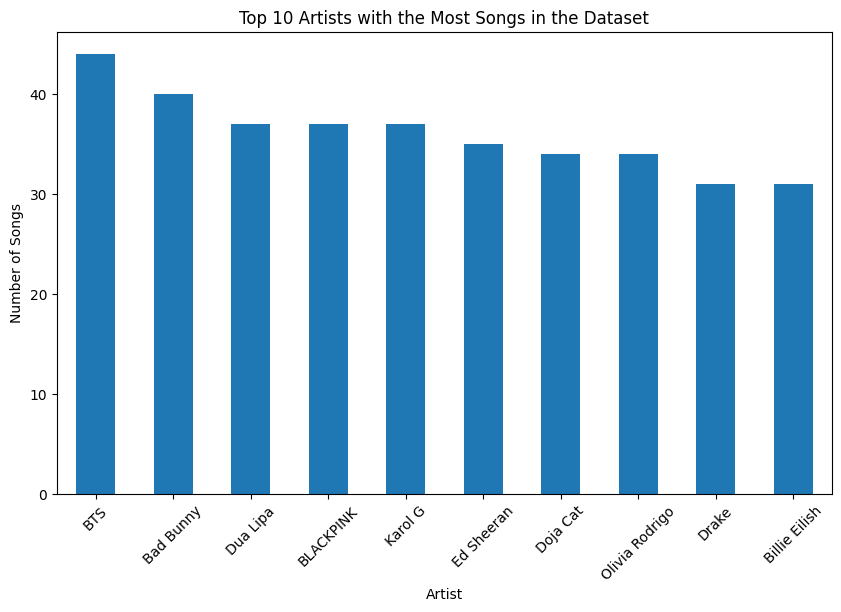

In [5]:
# plot the top 10 artists with the most songs in the dataset
import matplotlib.pyplot as plt
top_artists = df['Artist'].value_counts().head(10)
plt.figure(figsize=(10,6))
top_artists.plot(kind='bar')
plt.title('Top 10 Artists with the Most Songs in the Dataset')
plt.xlabel('Artist')
plt.ylabel('Number of Songs')
plt.xticks(rotation=45)
plt.show()

**2. Album**

What does Album represent?

Album is a content container useful for:

1. release-level performance

2. catalog longevity

3. comparing album impact vs single-track virality

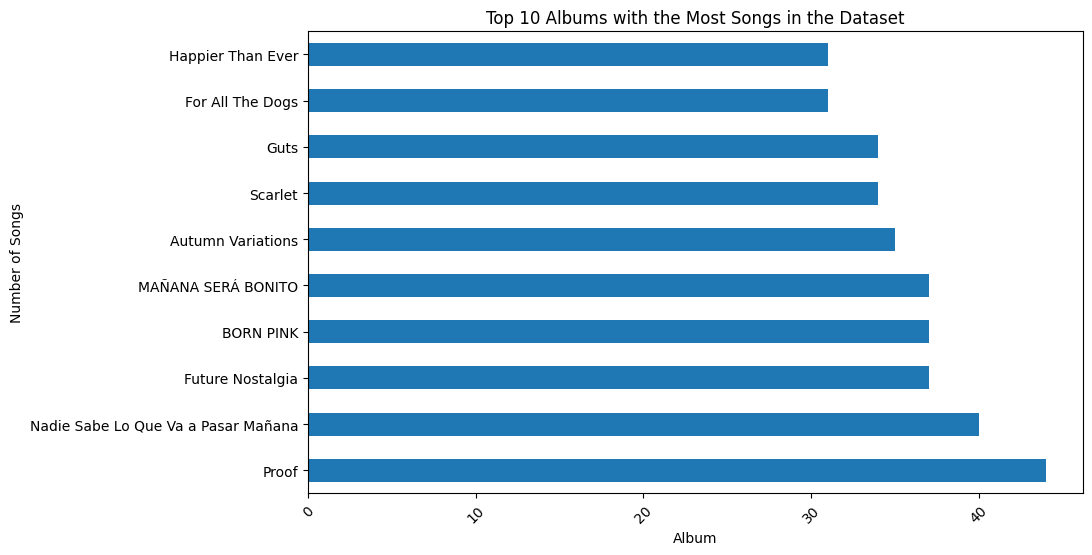

In [6]:
# plot top albums 
top_albums = df['Album'].value_counts().head(10)
plt.figure(figsize=(10,6)) 
top_albums.plot(kind='barh')
plt.title('Top 10 Albums with the Most Songs in the Dataset')
plt.xlabel('Album')
plt.ylabel('Number of Songs')   
plt.xticks(rotation=45)
plt.show()

**3. Genre**

What does Genre represent?

Genre is a content category segmentation feature.

Business use:

1. recommendation strategy

2. market-level preference

3. genre retention differences

In [7]:
df['Genre'].nunique()

10

In [8]:
df['Genre'].value_counts()

Genre
Classical    72
Rock         58
EDM          51
Indie        50
Hip Hop      49
K-pop        48
Pop          44
Reggaeton    44
Jazz         43
R&B          41
Name: count, dtype: int64

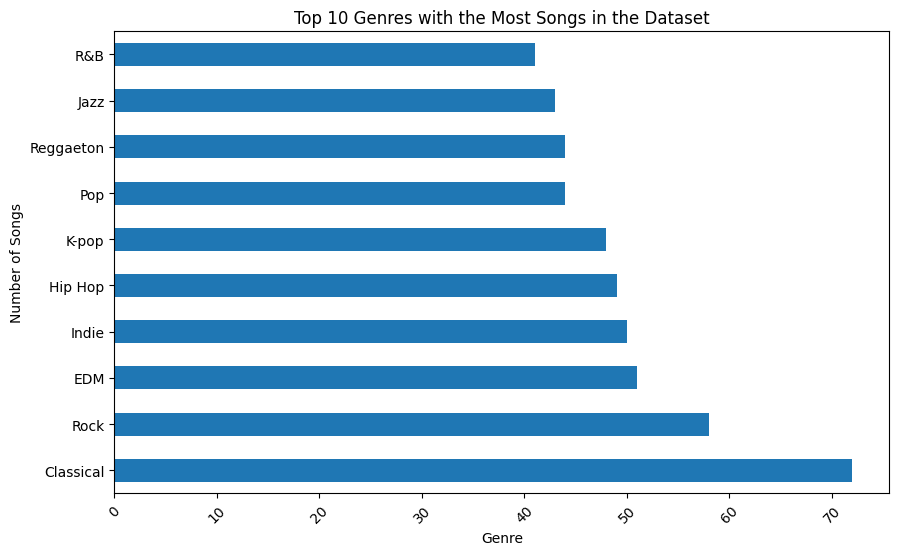

In [9]:
#plot the top 10 genres with the most songs in the dataset
top_genres = df['Genre'].value_counts().head(10)
plt.figure(figsize=(10,6))
top_genres.plot(kind='barh') 
plt.title('Top 10 Genres with the Most Songs in the Dataset')
plt.xlabel('Genre')
plt.ylabel('Number of Songs')
plt.xticks(rotation=45) 
plt.show()

**4. Release Year**

What does Release Year Represent?

this is the content lifecycle variable.

Spotify Question:

Do users Stream:

1. fresh releases?

2. evergreen catalog

In [10]:
df['Release Year'].min()
df['Release Year'].max()
df['Release Year'].value_counts().sort_index()

Release Year
2018     31
2019    174
2020     54
2021     37
2022     98
2023    106
Name: count, dtype: int64

#### Geographic/ Market Context - Country

In [11]:
df['Country'].nunique()


20

In [12]:
df['Country'].value_counts()

Country
Italy             34
South Africa      32
South Korea       31
Russia            31
Brazil            30
Sweden            30
Argentina         27
Spain             25
Canada            25
Indonesia         25
Mexico            24
Japan             23
France            23
Netherlands       23
India             22
United Kingdom    22
Turkey            22
Germany           20
United States     19
Australia         12
Name: count, dtype: int64

**Artist Distribution by Country**

Which artists dominate which markets?

1. localized marketing campaigns

2. regional playlist placement

3. touring/ partnerships

4. country-specific retention strategies

In [13]:
top_artists_country = (
    df.groupby(['Country', 'Artist'])
    .agg(total_streams=('Total Streams (Millions)', 'sum'))
    .reset_index()
    .sort_values(['Country', 'total_streams'], ascending=[True, False])
)

In [14]:
top_artist_country = (
    df.groupby(['Country', 'Artist'])
    .agg(total_streams=('Total Streams (Millions)', 'sum'))
    .reset_index()
)

dominant_artist = (
    top_artist_country
    .sort_values(['Country', 'total_streams'], ascending=[True, False])
    .groupby('Country')
    .first()
    .reset_index()
)

dominant_artist.head()


,Country,Artist,total_streams
0,Argentina,Doja Cat,13830.65
1,Australia,Olivia Rodrigo,7328.19
2,Brazil,BTS,11017.07
3,Canada,Dua Lipa,14393.34
4,France,BLACKPINK,9686.50


In [15]:
import pycountry

def get_iso2(name):
    try:
        return pycountry.countries.lookup(name).alpha_2
    except:
        return None

dominant_artist['ISO_A2'] = dominant_artist['Country'].apply(get_iso2)

dominant_artist[['Country', 'Artist', 'ISO_A2']]


,Country,Artist,ISO_A2
0,Argentina,Doja Cat,AR
1,Australia,Olivia Rodrigo,AU
2,Brazil,BTS,BR
3,Canada,Dua Lipa,CA
4,France,BLACKPINK,FR
5,Germany,Taylor Swift,DE
6,India,BTS,IN
7,Indonesia,BTS,ID
8,Italy,Ed Sheeran,IT
9,Japan,BLACKPINK,JP


In [16]:
dominant_artist['ISO_A2'].isna().sum()


np.int64(2)

In [17]:
dominant_artist[dominant_artist['ISO_A2'].isna()][['Country']]


,Country
12,Russia
17,Turkey


In [18]:
country_fix = {
    "Russia": "RU",
    "Turkey": "TR"
}

dominant_artist["ISO_A2"] = dominant_artist.apply(
    lambda row: country_fix[row["Country"]]
    if pd.isna(row["ISO_A2"]) and row["Country"] in country_fix
    else row["ISO_A2"],
    axis=1
)


In [19]:
dominant_artist["ISO_A2"].isna().sum()


np.int64(0)

In [20]:
dominant_artist.loc[dominant_artist['Country'] == 'United Kingdom', 'ISO_A2'] = 'GB'


In [20]:
import geopandas as gpd

url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)


In [21]:
world_merged = world.merge(
    dominant_artist,
    how='left',
    left_on='ISO_A2',
    right_on='ISO_A2'
)

world_merged[['NAME', 'Artist']].head()


,NAME,Artist
0,Fiji,NaN
1,Tanzania,NaN
2,W. Sahara,NaN
3,Canada,Dua Lipa
4,United States of America,BLACKPINK


In [22]:
top_artists_global = (
    dominant_artist['Artist']
    .value_counts()
    .head(6)
    .index
)

dominant_artist['Artist_Group'] = dominant_artist['Artist'].apply(
    lambda x: x if x in top_artists_global else "Other"
)


In [23]:
world_merged = world.merge(
    dominant_artist[['ISO_A2', 'Artist_Group']],
    how='left',
    on='ISO_A2'
)


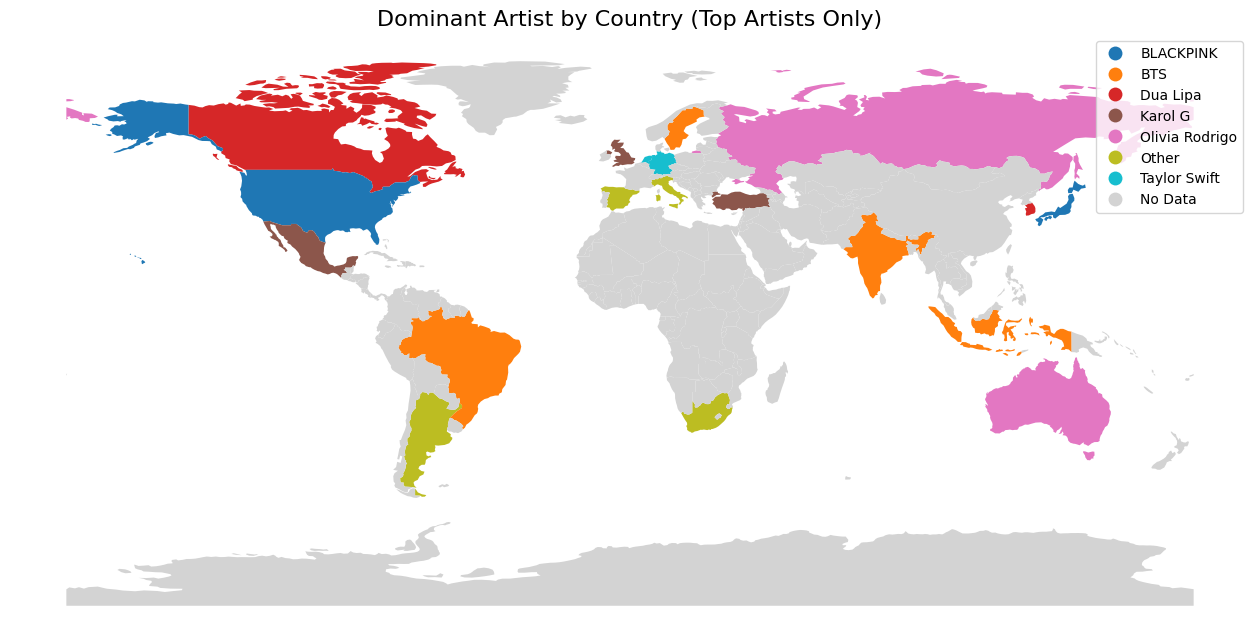

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 9))

world_merged.plot(
    ax=ax,
    column='Artist_Group',
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "label": "No Data"
    }
)

ax.set_title("Dominant Artist by Country (Top Artists Only)", fontsize=16)
ax.axis("off")
plt.show()


In [25]:
country_genre_dist = (
    df.groupby(["Country", "Genre"])
    .size()
    .reset_index(name="songs")
)

country_totals = (
    country_genre_dist
    .groupby("Country")["songs"]
    .sum()
    .reset_index(name="total_songs")
)

country_genre_pct = country_genre_dist.merge(country_totals, on="Country")

country_genre_pct["pct"] = (
    country_genre_pct["songs"] / country_genre_pct["total_songs"]
)

dominant_genre_country = (
    country_genre_pct
    .sort_values(["Country", "pct"], ascending=[True, False])
    .groupby("Country")
    .first()
    .reset_index()
)


In [26]:
import pycountry

def get_iso2(name):
    try:
        return pycountry.countries.lookup(name).alpha_2
    except:
        return None

dominant_genre_country["ISO_A2"] = dominant_genre_country["Country"].apply(get_iso2)


In [27]:
dominant_genre_country["ISO_A2"] = dominant_genre_country["ISO_A2"].replace({
    None: "RU"  # Russia sometimes fails
})

dominant_genre_country.loc[
    dominant_genre_country["Country"] == "Turkey", "ISO_A2"
] = "TR"


In [28]:
world_merged = world.merge(
    dominant_genre_country[["ISO_A2", "Genre"]],
    how="left",
    on="ISO_A2"
)


In [29]:
print(world_merged["Genre"].notna().sum())
print(world_merged["Genre"].value_counts())


19
Genre
Classical    8
Indie        3
EDM          3
K-pop        1
Rock         1
Pop          1
Jazz         1
Hip Hop      1
Name: count, dtype: int64


In [30]:
genre_colors = {
    "Pop": "#ff9999",
    "Rock": "#66b3ff",
    "Hip Hop": "#99ff99",
    "EDM": "#ffcc99",
    "Classical": "#c2c2f0",
    "Jazz": "#f0e68c",
    "Indie": "#deb887",
    "K-pop": "#ffb3e6",
    "Reggaeton": "#ffa07a",
    "R&B": "#9da91c"
}

world_merged["genre_color"] = (
    world_merged["Genre"]
    .map(genre_colors)
    .fillna("lightgrey")
)


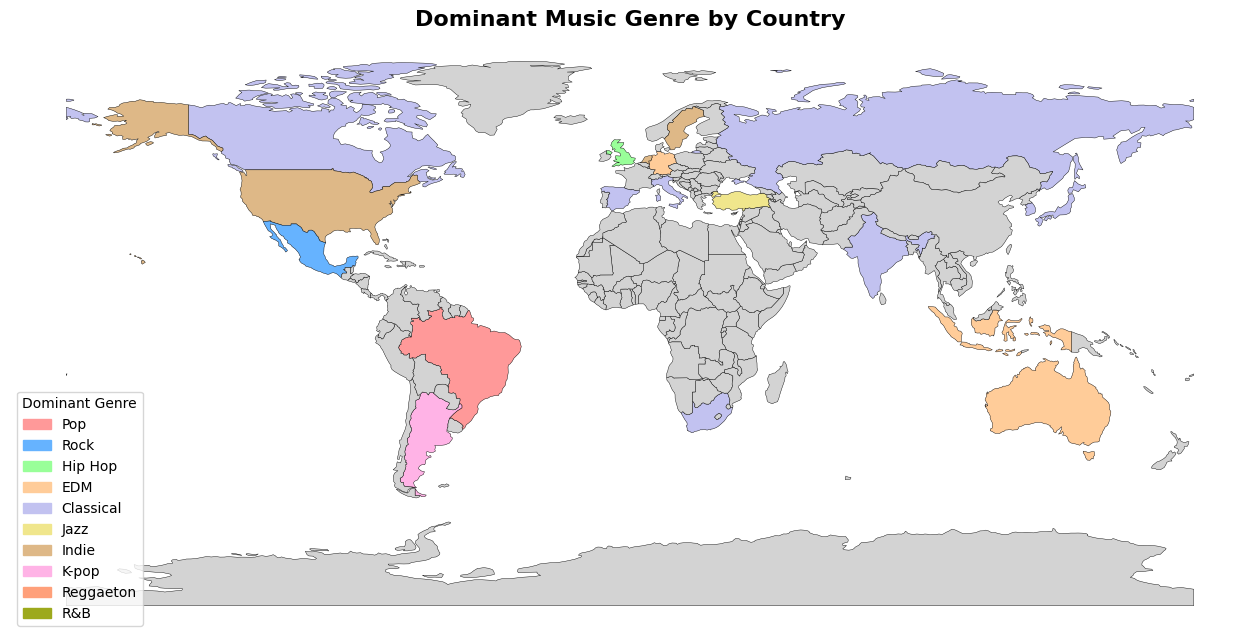

In [31]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(16, 9))

world_merged.plot(
    ax=ax,
    color=world_merged["genre_color"],
    edgecolor="black",
    linewidth=0.3
)

# Legend
legend_patches = [
    mpatches.Patch(color=color, label=genre)
    for genre, color in genre_colors.items()
]

ax.legend(
    handles=legend_patches,
    title="Dominant Genre",
    loc="lower left",
    frameon=True
)

ax.set_title("Dominant Music Genre by Country", fontsize=16, weight="bold")
ax.axis("off")

plt.show()


In [32]:
dominant_genre_country["dominance_strength"] = dominant_genre_country["pct"]


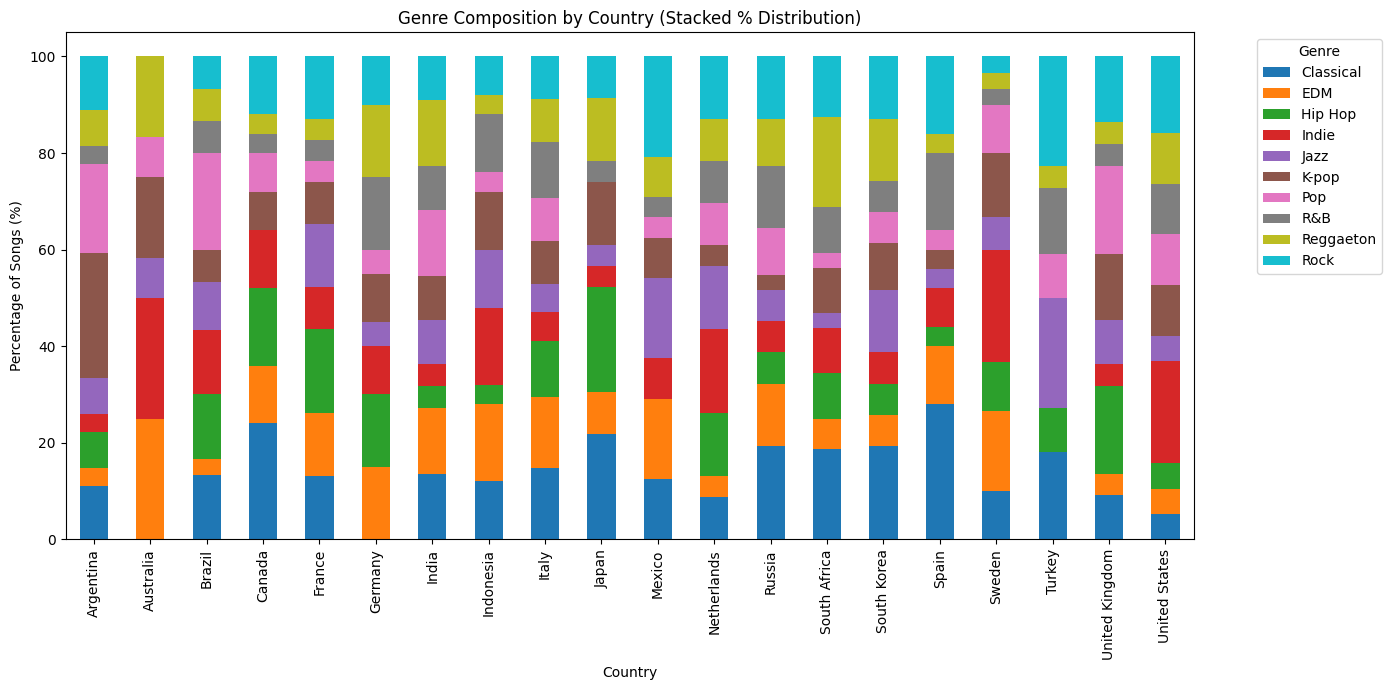

In [33]:

# Step 1: Count songs per Country × Genre
country_genre_counts = (
    df.groupby(["Country", "Genre"])
    .size()
    .reset_index(name="songs")
)

# Step 2: Convert to pivot table
country_genre_pivot = country_genre_counts.pivot(
    index="Country",
    columns="Genre",
    values="songs"
).fillna(0)

# Step 3: Convert counts → percentages
country_genre_pct = country_genre_pivot.div(
    country_genre_pivot.sum(axis=1),
    axis=0
) * 100

# Step 4: Plot stacked bar chart
country_genre_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("Genre Composition by Country (Stacked % Distribution)")
plt.ylabel("Percentage of Songs (%)")
plt.xlabel("Country")
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


### 🌍 Country Feature — Market Context Findings (Spotify Global Streaming 2024)

#### Why we looked at Country

The `Country` column is not a churn or behavioral feature here.

It acts as a market segmentation dimension, helping answer:

* How streaming activity is distributed geographically
* Whether certain artists dominate specific markets
* Whether genre preference is regionally concentrated or globally uniform

This feature is mainly useful for:

* Dashboard navigation
* Market-level storytelling
* Regional catalog strategy context

---

#### Dataset Coverage Reality Check

We confirmed that the dataset contains:

* 500 songs
* 20 countries
* No missing values in Country

Country distribution is fairly balanced:

* Italy (34), South Africa (32), South Korea (31), Russia (31)…
* Australia is the smallest market in this dataset (12 entries)

So geographic analysis is feasible without heavy bucketing.

---

#### Key Discovery 1 — Dominant Artist Maps Work Cleanly

We computed the top-streamed artist per country.

Example output:

| Country | Dominant Artist |
|---------|----------------|
| Brazil | BTS |
| Canada | Dua Lipa |
| US | BLACKPINK |
| Italy | Ed Sheeran |

**Visualization: Dominant Artist by Country Map**

This map produced a clean, interpretable distribution:

* Global artists repeat across markets
* Superstar dominance is cross-regional rather than isolated

📌 **Insight:**

Spotify's global catalog is not fragmented — top artists penetrate multiple countries simultaneously.

---

#### Key Discovery 2 — Genre Map Initially Failed Due to Merge Logic

When mapping dominant genre, we hit a major issue:
```python
print(world_merged["Genre"].notna().sum())
# Output: 0
```

Even though dominant genres existed in our country table.

##### Root Cause

Mismatch between merge keys:

* Map dataset uses ISO codes (`ISO_A2`)
* Our dominant genre table still contained full country names

So nothing matched → entire map became "No Data".

This was not a visualization problem. It was a data integration problem.

---

#### Key Fix — Standardizing ISO Codes Properly

Once we mapped country names → ISO codes correctly:

* Russia and Turkey were missing initially
* Fixed with manual overrides

After correction, genre dominance finally plotted correctly.

---

#### Key Discovery 3 — Dominant Genre Map Alone Is Misleading

The genre dominance map produced this result:

* Classical appears dominant in 8 countries
* Indie and EDM appear in 3 each
* Others appear rarely

But dominance here only means:

**"Highest share among genres"**

Not:

**"Majority of listening"**

So the map answers:

**Which genre leads?**

But not:

**How strongly does it lead?**

---

#### Key Discovery 4 — The 100% Stacked Bar Completes the Story

To validate whether genre dominance was meaningful, we plotted:

**Genre Composition by Country (100% Stacked Bar)**

This revealed the truth:

* Most countries are genre-diverse
* Dominant genres often only lead by small margins
* Classical dominance does not mean monoculture

📌 **Insight:**

Spotify markets are not single-genre markets. They are multi-genre ecosystems with slight leaders.

---

#### Final Country-Level Insight Summary

Country feature contributes primarily as a context layer, not a churn driver.

**What it enables:**

* Geographic market segmentation
* Artist penetration mapping
* Genre preference direction per region

**What it does NOT imply:**

* Strong churn causality
* Single-genre national identity
* Deep behavioral risk signal

---

#### Dashboard Readiness

Country is best used as:

* Filter
* Region slicer
* Market comparison dimension

Not as a standalone KPI driver.

#### Scale of Reach - Monthly Listeners (Millions)

In [34]:
df['Monthly Listeners (Millions)'].describe()

count    500.00000
mean      51.04122
std       28.23801
min        1.01000
25%       27.67250
50%       50.82500
75%       75.09500
max       99.80000
Name: Monthly Listeners (Millions), dtype: float64

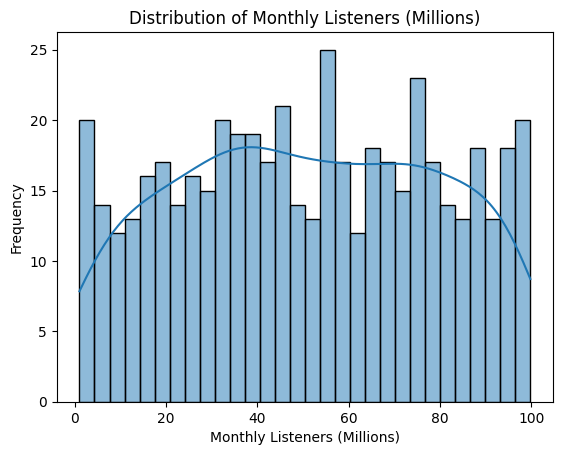

In [35]:
import seaborn as sns
sns.histplot(df['Monthly Listeners (Millions)'], bins=30, kde=True)
plt.title('Distribution of Monthly Listeners (Millions)')
plt.xlabel('Monthly Listeners (Millions)')
plt.ylabel('Frequency')
plt.show()

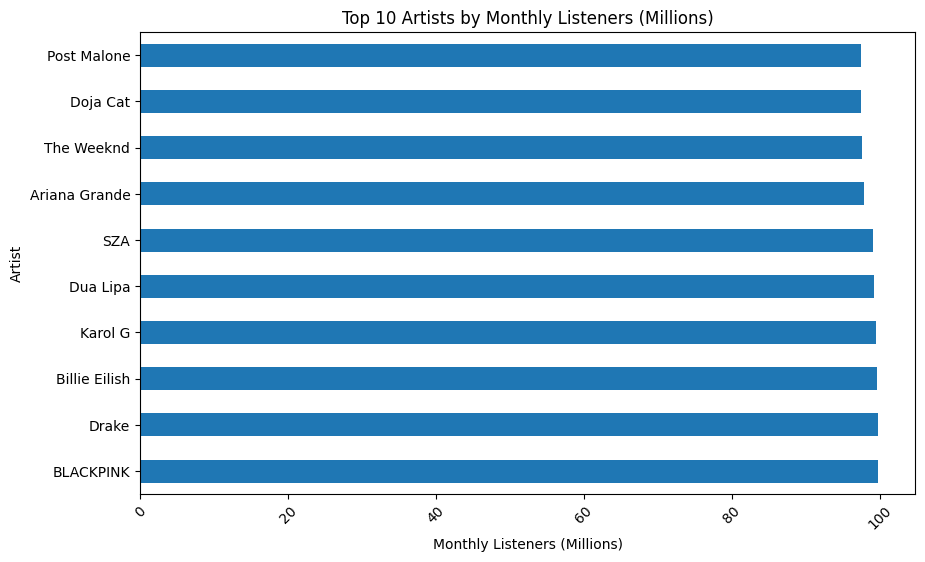

In [36]:
# print the montlhy listeners for the top 10 artists
top_artists_listeners = (
    df.groupby('Artist')['Monthly Listeners (Millions)']
    .max()
    .sort_values(ascending=False)
    .head(10)
)
top_artists_listeners.plot(kind='barh', figsize=(10,6))
plt.title('Top 10 Artists by Monthly Listeners (Millions)')
plt.xlabel('Monthly Listeners (Millions)')
plt.ylabel('Artist')
plt.xticks(rotation=45)
plt.show()

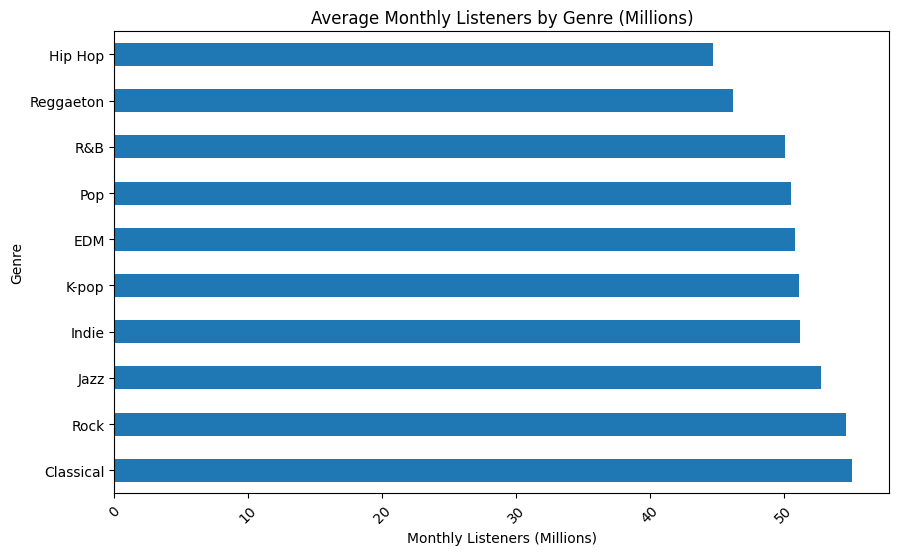

In [37]:
# monthly listeners by genre
genre_listeners = (
    df.groupby('Genre')['Monthly Listeners (Millions)']
    .mean()
    .sort_values(ascending=False)
)
genre_listeners.plot(kind='barh', figsize=(10,6))
plt.title('Average Monthly Listeners by Genre (Millions)')
plt.xlabel('Monthly Listeners (Millions)')
plt.ylabel('Genre')
plt.xticks(rotation=45)
plt.show()

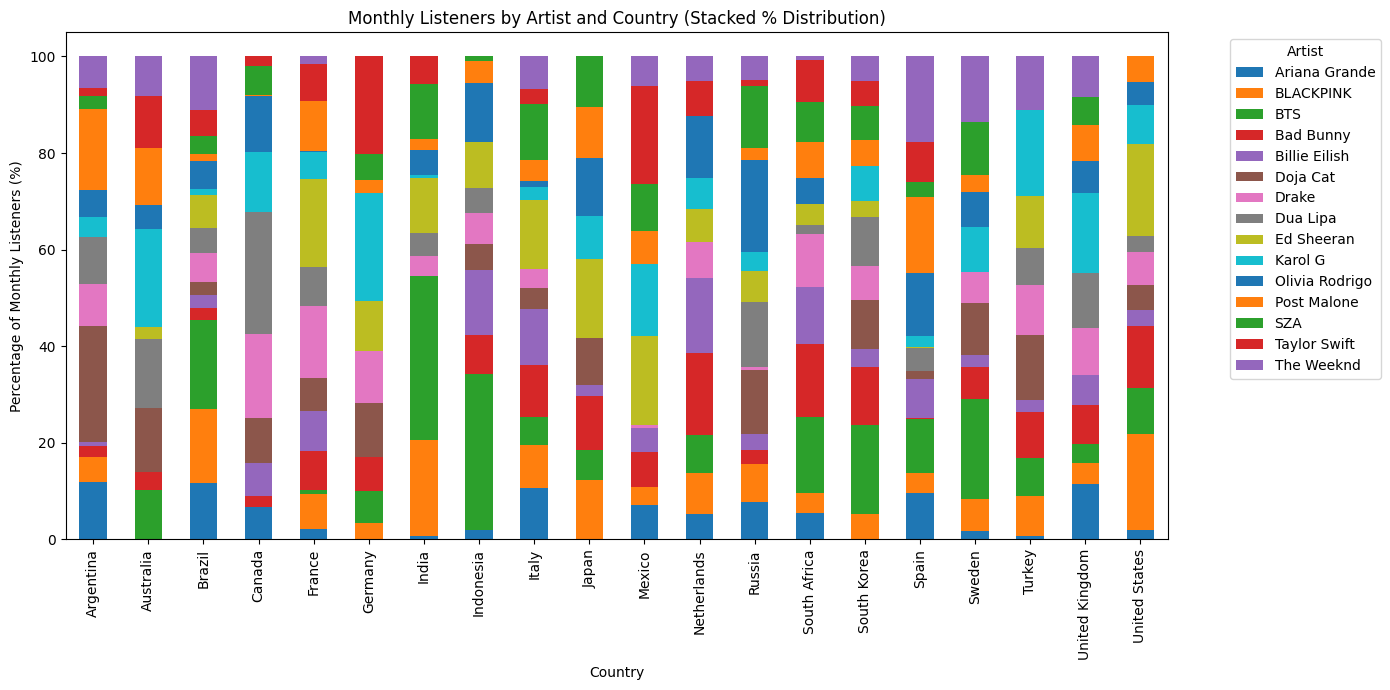

In [38]:
# plot 100% stacked bar chart of monthly listeners of artists by country
country_artist_listeners = (
    df.groupby(['Country', 'Artist'])['Monthly Listeners (Millions)']
    .sum()
    .reset_index()
)
country_artist_pivot = country_artist_listeners.pivot(
    index='Country',
    columns='Artist',
    values='Monthly Listeners (Millions)'
)
country_artist_pct = country_artist_pivot.div(
    country_artist_pivot.sum(axis=1),
    axis=0
) * 100
country_artist_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7)
)
plt.title('Monthly Listeners by Artist and Country (Stacked % Distribution)')
plt.ylabel('Percentage of Monthly Listeners (%)')
plt.xlabel('Country')
plt.legend(title='Artist', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


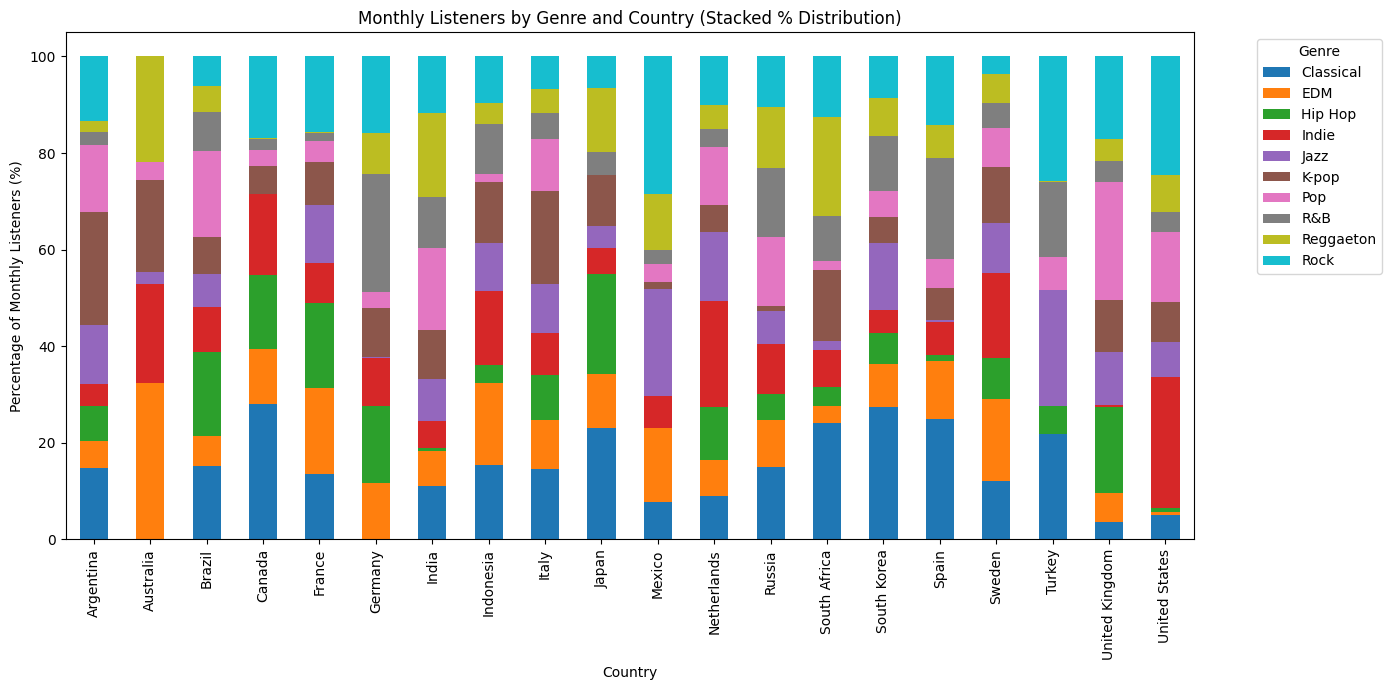

In [39]:
# plot a 100% stacked bar chart of monthly listeners of genres by country
country_genre_listeners = (
    df.groupby(['Country', 'Genre'])['Monthly Listeners (Millions)']
    .sum()
    .reset_index()
)
country_genre_pivot = country_genre_listeners.pivot(
    index='Country',
    columns='Genre',
    values='Monthly Listeners (Millions)'
)
country_genre_pct = country_genre_pivot.div(
    country_genre_pivot.sum(axis=1),
    axis=0
) * 100
country_genre_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7)
)
plt.title('Monthly Listeners by Genre and Country (Stacked % Distribution)')
plt.ylabel('Percentage of Monthly Listeners (%)')
plt.xlabel('Country')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [40]:

# Define reach cohorts (business-friendly)

bins = [0, 10, 50, df["Monthly Listeners (Millions)"].max()]
labels = ["Emerging (<10M)", "Mid-Tier (10–50M)", "Superstar (50M+)"]

df["reach_cohort"] = pd.cut(
    df["Monthly Listeners (Millions)"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Check distribution
df["reach_cohort"].value_counts()


reach_cohort
Superstar (50M+)     254
Mid-Tier (10–50M)    203
Emerging (<10M)       43
Name: count, dtype: int64

In [41]:
reach_dist = (
    df["reach_cohort"]
    .value_counts(normalize=True)
    .reset_index()
)

reach_dist.columns = ["reach_cohort", "proportion"]
reach_dist["pct"] = reach_dist["proportion"] * 100

reach_dist


,reach_cohort,proportion,pct
0,Superstar (50M+),0.508,50.8
1,Mid-Tier (10–50M),0.406,40.6
2,Emerging (<10M),0.086,8.6


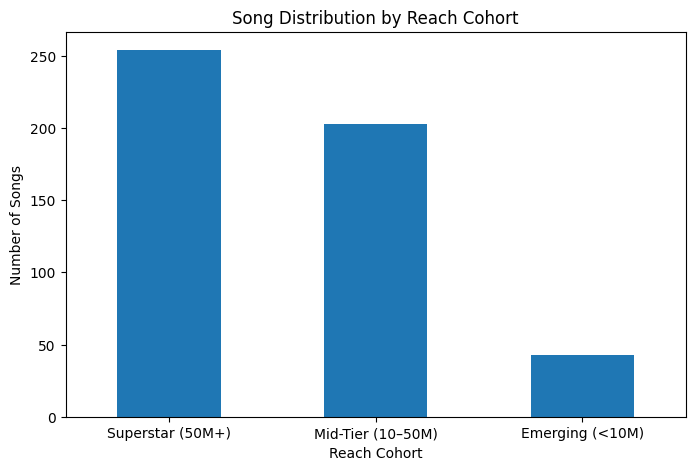

In [42]:
import matplotlib.pyplot as plt

reach_counts = df["reach_cohort"].value_counts()

plt.figure(figsize=(8,5))
reach_counts.plot(kind="bar")

plt.title("Song Distribution by Reach Cohort")
plt.xlabel("Reach Cohort")
plt.ylabel("Number of Songs")
plt.xticks(rotation=0)

plt.show()


C:\Users\adith\AppData\Local\Temp\ipykernel_39316\519536951.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Artist", "reach_cohort"])


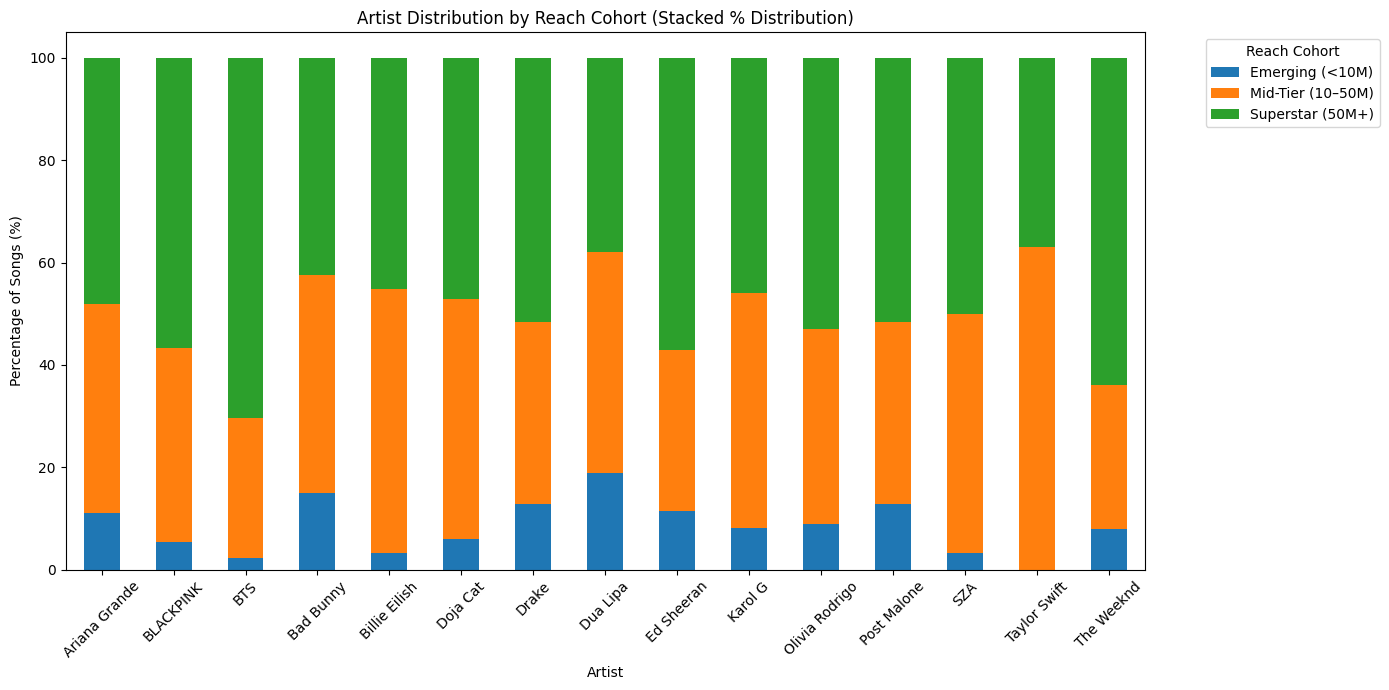

In [43]:
# plot artists by reach cohort
artist_reach = (
    df.groupby(["Artist", "reach_cohort"])
    .size()
    .reset_index(name="song_count")
)
artist_reach_pivot = artist_reach.pivot(
    index="Artist",
    columns="reach_cohort",
    values="song_count"
).fillna(0)
artist_reach_pct = artist_reach_pivot.div(
    artist_reach_pivot.sum(axis=1),
    axis=0
) * 100
artist_reach_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)
plt.title("Artist Distribution by Reach Cohort (Stacked % Distribution)")
plt.ylabel("Percentage of Songs (%)")
plt.xlabel("Artist")
plt.legend(title="Reach Cohort", bbox_to_anchor=(1.05, 1),
              loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Feature: Monthly Listeners (Millions)

This feature represents the global reach of an artist/song, measuring how many unique listeners engage monthly.

It is a strong indicator of:

* Popularity scale
* Market penetration
* Audience size tier (emerging vs superstar)

---

##### 1. Distribution of Monthly Listeners

The dataset shows a wide spread of reach:

* Values range from very small listener bases (~1–5M)
* Up to extremely high reach (~100M)

The distribution is relatively broad, with many songs clustered in the mid-to-high listener region.

📌 **Visualization used:**

* Histogram + KDE curve

---

##### 2. Top Artists by Monthly Reach

The highest monthly listener counts belong to global superstar artists.

Top examples:

* BLACKPINK
* Drake
* Billie Eilish
* Dua Lipa
* Post Malone

This confirms the dataset contains mostly globally mainstream performers.

📌 **Visualization used:**

* Horizontal bar chart (Top 10 artists)

---

##### 3. Genre-Level Reach Differences

We computed average monthly listeners by genre.

Observations:

* Classical and Rock show high average reach
* Hip Hop shows relatively lower average reach in this dataset

This indicates genre popularity varies, but not dramatically.

📌 **Visualization used:**

* Genre-level bar chart

---

##### 4. Country-Level Listener Composition

We explored whether countries are dominated by specific artists or genres.

Two stacked 100% charts were used:

* Artist share per country
* Genre share per country

This revealed:

* Most countries are multi-genre
* Dominance is rarely absolute

---

##### 5. Reach Cohort Bucketing

To make the metric business interpretable, we created reach cohorts:

| Cohort | Definition |
|--------|-----------|
| Emerging | <10M listeners |
| Mid-Tier | 10–50M |
| Superstar | 50M+ |

Resulting distribution:

* Superstar (50M+) → 254 songs
* Mid-Tier (10–50M) → 203 songs
* Emerging (<10M) → 43 songs

📌 **Visualization used:**

* Cohort bar chart

---

##### 6. Artist Reach Cohort Breakdown

Artists are mostly concentrated in Superstar and Mid-Tier tiers.

Emerging reach songs are relatively rare in this dataset.

📌 **Visualization used:**

* Stacked cohort distribution by artist

---

##### Key Notebook Conclusion

Monthly listeners is a strong scale-of-reach feature, and cohorting makes it dashboard-ready.

#### Consumption Volume Metrics (Core KPIs)

These represent what the platform earns attention through.

| Feature | KPI Type |
|---------|----------|
| Total Streams (Millions) | Lifetime consumption volume |
| Streams Last 30 Days (Millions) | Recency-weighted momentum |
| Total Hours Streamed (Millions) | Time-based consumption volume |

These are your primary performance KPIs.

**1. Total Streams (Millions)**

In [45]:
df['Total Streams (Millions)'].describe()

count     500.000000
mean     2581.154080
std      1416.055972
min        53.560000
25%      1337.337500
50%      2697.355000
75%      3798.197500
max      4985.540000
Name: Total Streams (Millions), dtype: float64

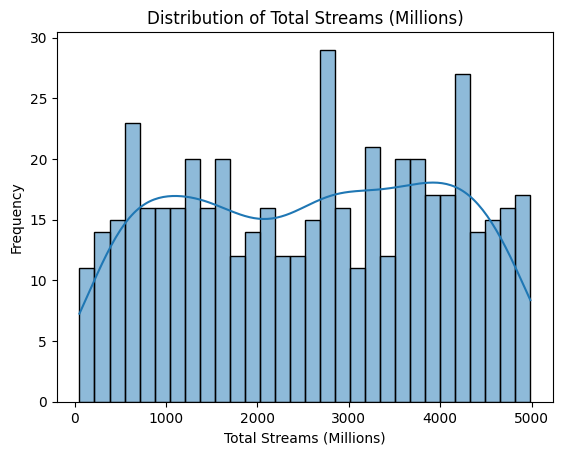

In [44]:
# plot the distribution of total streams
sns.histplot(df['Total Streams (Millions)'], bins=30, kde=True)
plt.title('Distribution of Total Streams (Millions)')
plt.xlabel('Total Streams (Millions)')
plt.ylabel('Frequency')
plt.show()


C:\Users\adith\AppData\Local\Temp\ipykernel_39316\1831987408.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Total Streams (Millions)'], bins=30, kde=True)


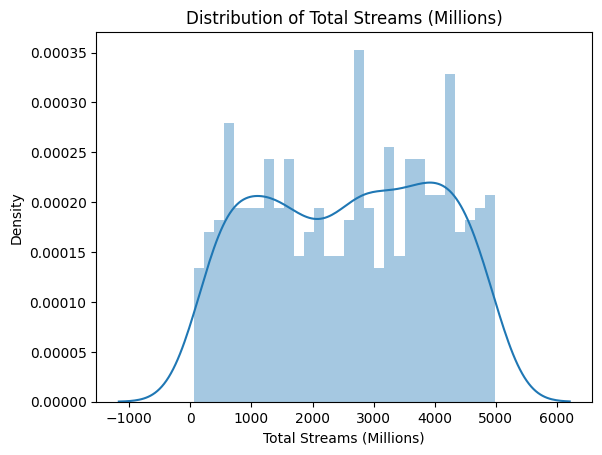

In [45]:
sns.distplot(df['Total Streams (Millions)'], bins=30, kde=True)
plt.title('Distribution of Total Streams (Millions)')
plt.xlabel('Total Streams (Millions)')
plt.ylabel('Density')
plt.show()

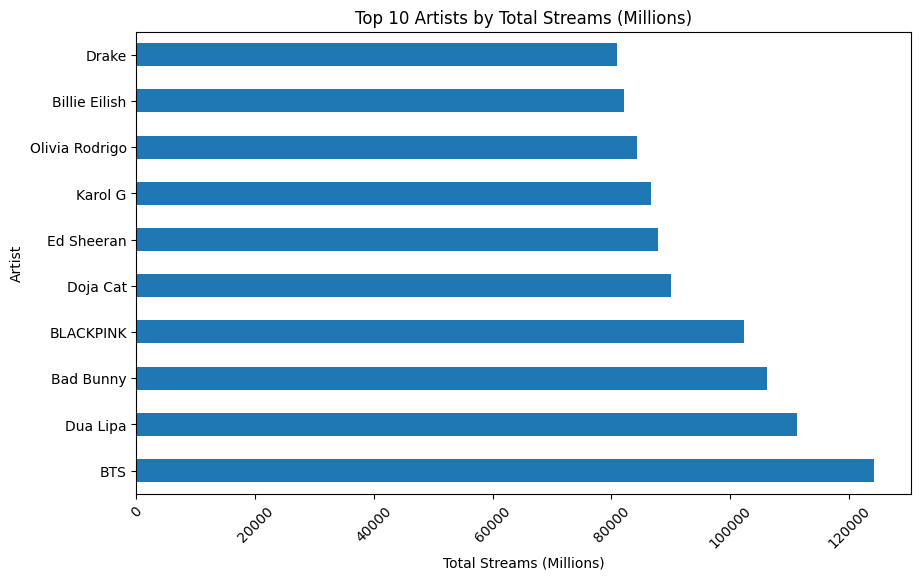

In [46]:
# plot artists by total streams
artist_streams = (
    df.groupby('Artist')['Total Streams (Millions)']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
artist_streams.plot(kind='barh', figsize=(10,6))
plt.title('Top 10 Artists by Total Streams (Millions)')
plt.xlabel('Total Streams (Millions)')
plt.ylabel('Artist')
plt.xticks(rotation=45)
plt.show()

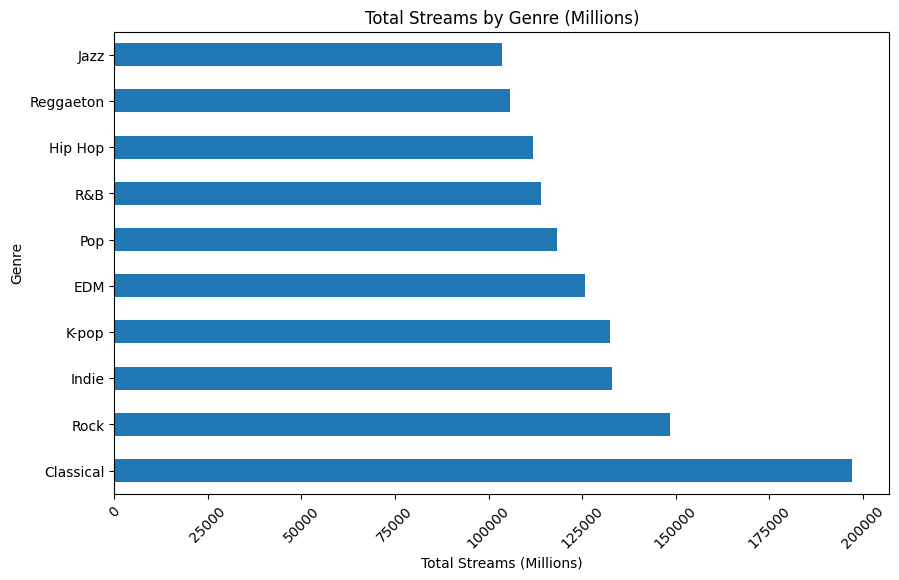

In [47]:
# plot genre by total streams
genre_streams = (
    df.groupby('Genre')['Total Streams (Millions)']
    .sum()
    .sort_values(ascending=False)
)
genre_streams.plot(kind='barh', figsize=(10,6))
plt.title('Total Streams by Genre (Millions)')
plt.xlabel('Total Streams (Millions)')
plt.ylabel('Genre')
plt.xticks(rotation=45)
plt.show()

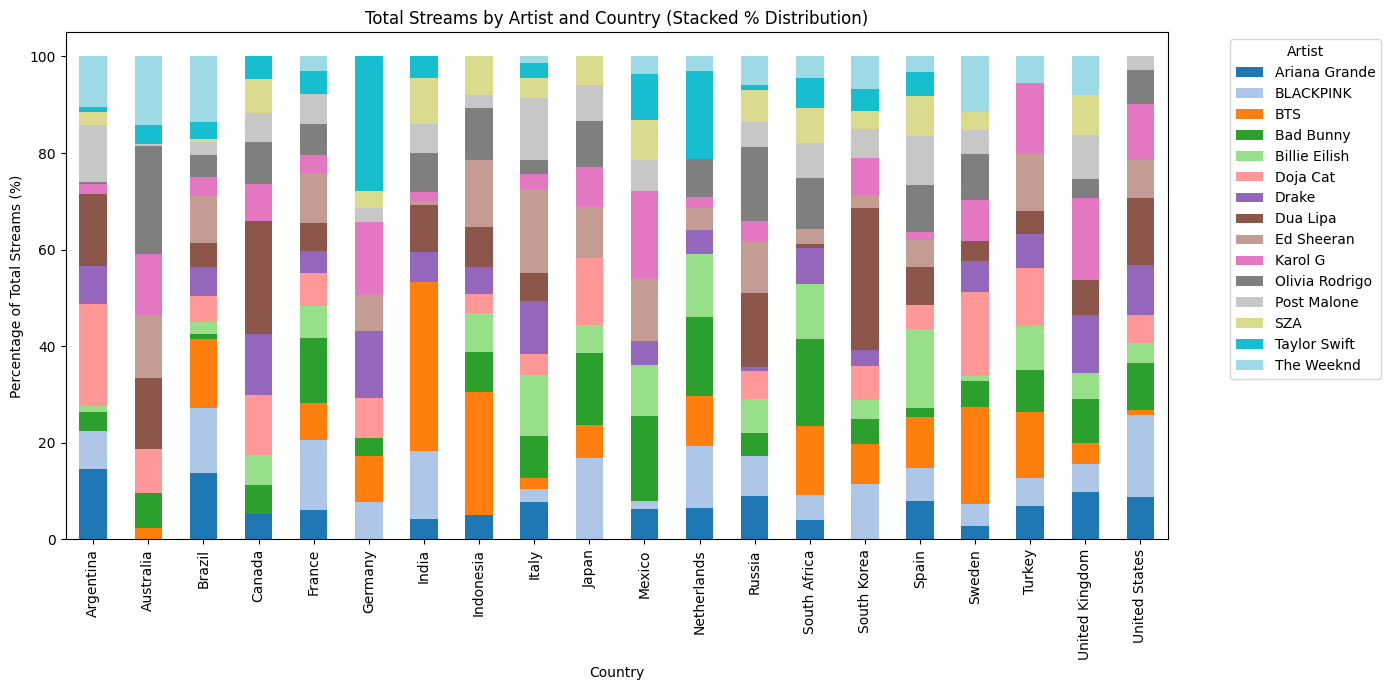

In [48]:
# plot the artist total streams distribution by country using a 100% stacked bar chart with different color codes for each artist
country_artist_streams = (
    df.groupby(['Country', 'Artist'])['Total Streams (Millions)']
    .sum()
    .reset_index()
)
country_artist_pivot = country_artist_streams.pivot(
    index='Country',
    columns='Artist',
    values='Total Streams (Millions)'
)
country_artist_pct = country_artist_pivot.div(
    country_artist_pivot.sum(axis=1),
    axis=0
) * 100
country_artist_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    colormap='tab20'
)
plt.title('Total Streams by Artist and Country (Stacked % Distribution)')
plt.ylabel('Percentage of Total Streams (%)')
plt.xlabel('Country')
plt.legend(title='Artist', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

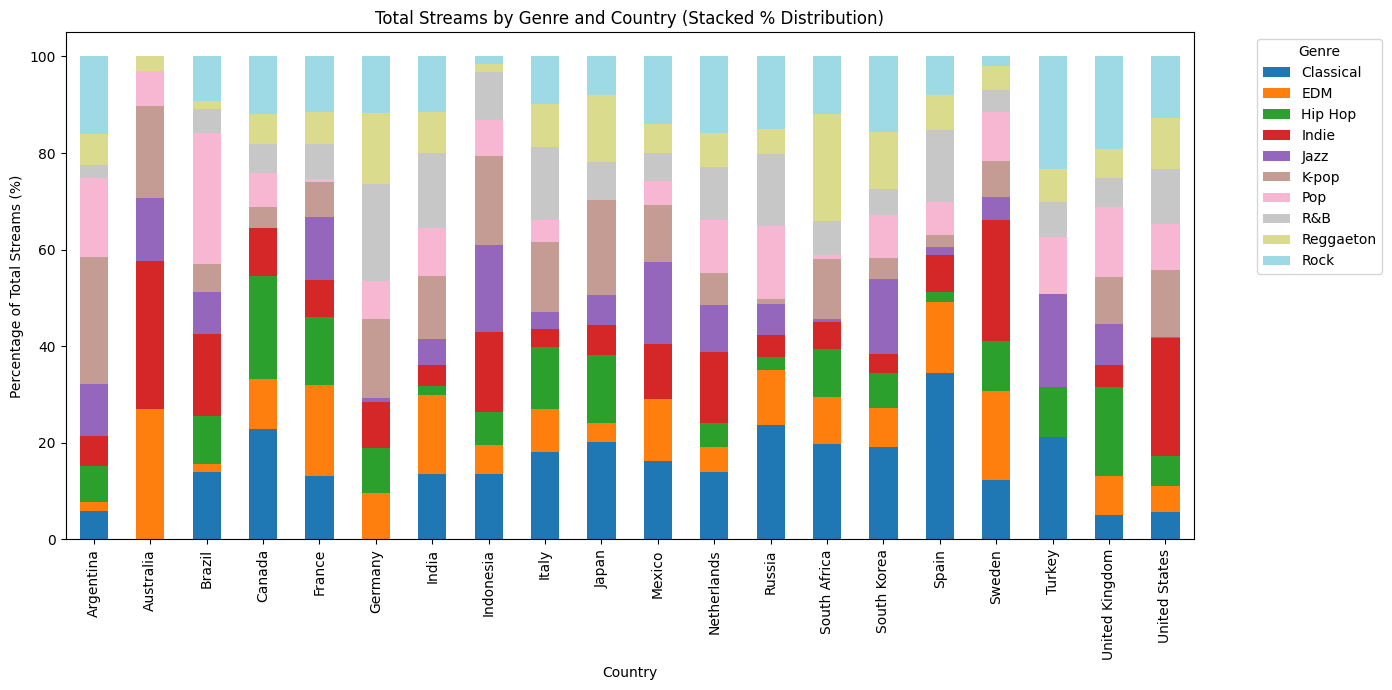

In [49]:
# plot genres by total streams by country using a 100% stacked bar chart with different color codes for each genre
country_genre_streams = (
    df.groupby(['Country', 'Genre'])['Total Streams (Millions)']
    .sum()
    .reset_index()
)
country_genre_pivot = country_genre_streams.pivot(
    index='Country',
    columns='Genre',
    values='Total Streams (Millions)'
)
country_genre_pct = country_genre_pivot.div(
    country_genre_pivot.sum(axis=1),
    axis=0
) * 100
country_genre_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    colormap='tab20'
)
plt.title('Total Streams by Genre and Country (Stacked % Distribution)')
plt.ylabel('Percentage of Total Streams (%)')
plt.xlabel('Country')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

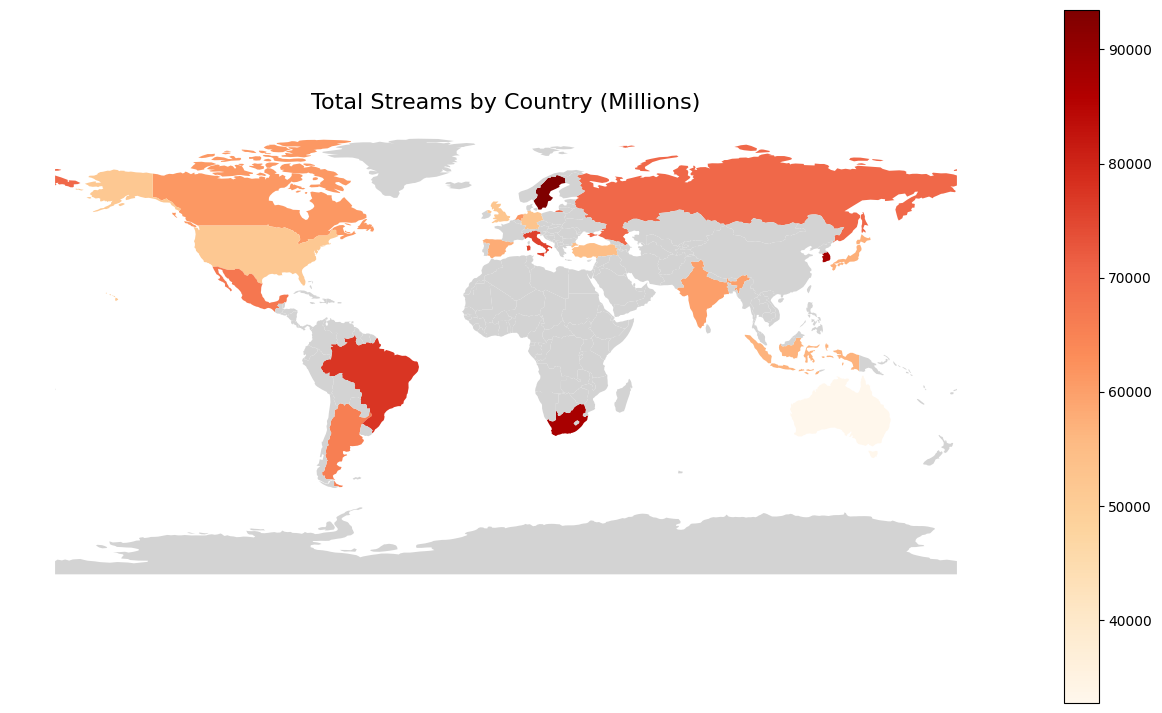

In [50]:
# plot a map of distribution of total streams by country with a map chart where the color intensity represents the total streams in millions
country_streams = (
    df.groupby('Country')['Total Streams (Millions)']
    .sum()
    .reset_index()
)
country_streams['ISO_A2'] = country_streams['Country'].apply(get_iso2)
country_streams['ISO_A2'] = country_streams['ISO_A2'].replace({
    None: 'RU'  # Russia sometimes fails
})
country_streams.loc[country_streams['Country'] == 'Turkey', 'ISO_A2'] = 'TR'
world_merged = world.merge(
    country_streams[['ISO_A2', 'Total Streams (Millions)']],
    how='left',
    on='ISO_A2'
)
fig, ax = plt.subplots(figsize=(16, 9))
world_merged.plot(
    ax=ax,
    column='Total Streams (Millions)',
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "label": "No Data"
    },
    cmap='OrRd'
)
ax.set_title("Total Streams by Country (Millions)", fontsize=16)
ax.axis("off")
plt.show()

In [51]:
# print artists with total streams 
artist_total_streams = (
    df.groupby('Artist')['Total Streams (Millions)']
    .sum()
    .sort_values(ascending=False)
)
artist_total_streams.head


<bound method NDFrame.head of Artist
BTS               124299.47
Dua Lipa          111305.99
Bad Bunny         106216.16
BLACKPINK         102238.89
Doja Cat           90098.83
Ed Sheeran         87859.35
Karol G            86737.71
Olivia Rodrigo     84378.54
Billie Eilish      82174.91
Drake              80948.91
Ariana Grande      77463.84
Post Malone        74873.69
The Weeknd         63099.45
Taylor Swift       61295.49
SZA                57585.81
Name: Total Streams (Millions), dtype: float64>

In [52]:
# print the genre with total streams
genre_total_streams = (
    df.groupby('Genre')['Total Streams (Millions)']
    .sum()
    .sort_values(ascending=False)
)
genre_total_streams.head()

Genre
Classical    197276.79
Rock         148418.93
Indie        133083.47
K-pop        132513.20
EDM          125801.69
Name: Total Streams (Millions), dtype: float64

**2. Streams Last 30 days (millions)**

this is Spotify's strongest proxy for:

--> Current popularity

--> Short-term engagement

--> Recent listener momentum

--> Trend velocity

the question is:

**Who is driving streaming activity this month?**


In [53]:
df['Streams Last 30 Days (Millions)'].describe()

count    500.000000
mean      99.048500
std       57.533452
min        2.850000
25%       48.057500
50%      101.465000
75%      148.410000
max      200.000000
Name: Streams Last 30 Days (Millions), dtype: float64

C:\Users\adith\AppData\Local\Temp\ipykernel_39316\3016118049.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Streams Last 30 Days (Millions)'], bins=30, kde=True)


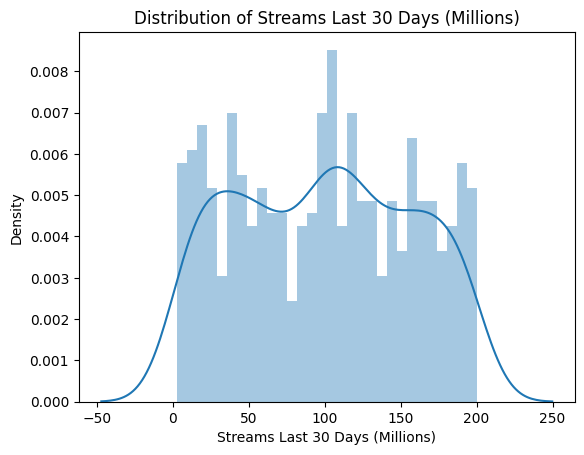

In [54]:
# plot the distribution of streams last 30 days
sns.distplot(df['Streams Last 30 Days (Millions)'], bins=30, kde=True)
plt.title('Distribution of Streams Last 30 Days (Millions)')
plt.xlabel('Streams Last 30 Days (Millions)')
plt.ylabel('Density')
plt.show()

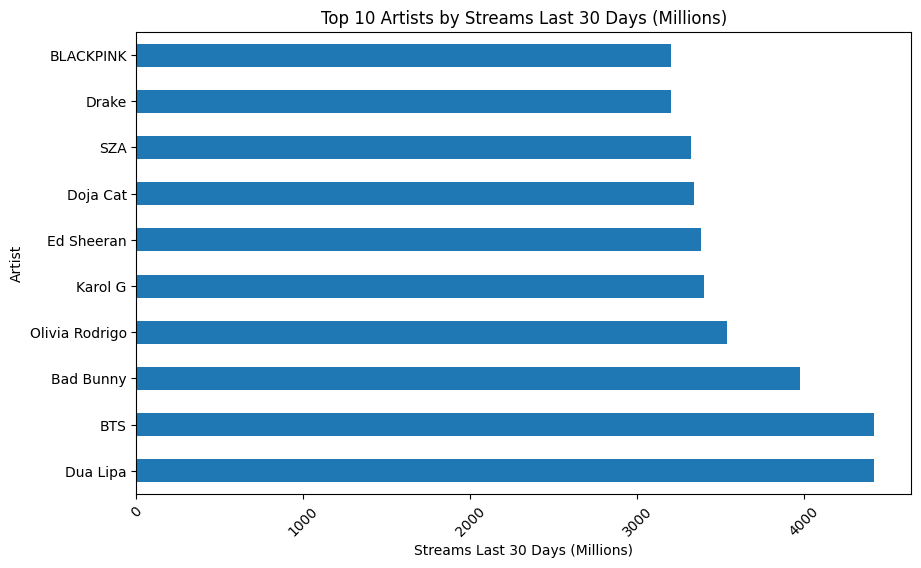

In [55]:
# plot the top artists by streams last 30 days
artist_streams_30d = (
    df.groupby('Artist')['Streams Last 30 Days (Millions)']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
artist_streams_30d.plot(kind='barh', figsize=(10,6))
plt.title('Top 10 Artists by Streams Last 30 Days (Millions)')
plt.xlabel('Streams Last 30 Days (Millions)')
plt.ylabel('Artist')
plt.xticks(rotation=45)
plt.show()

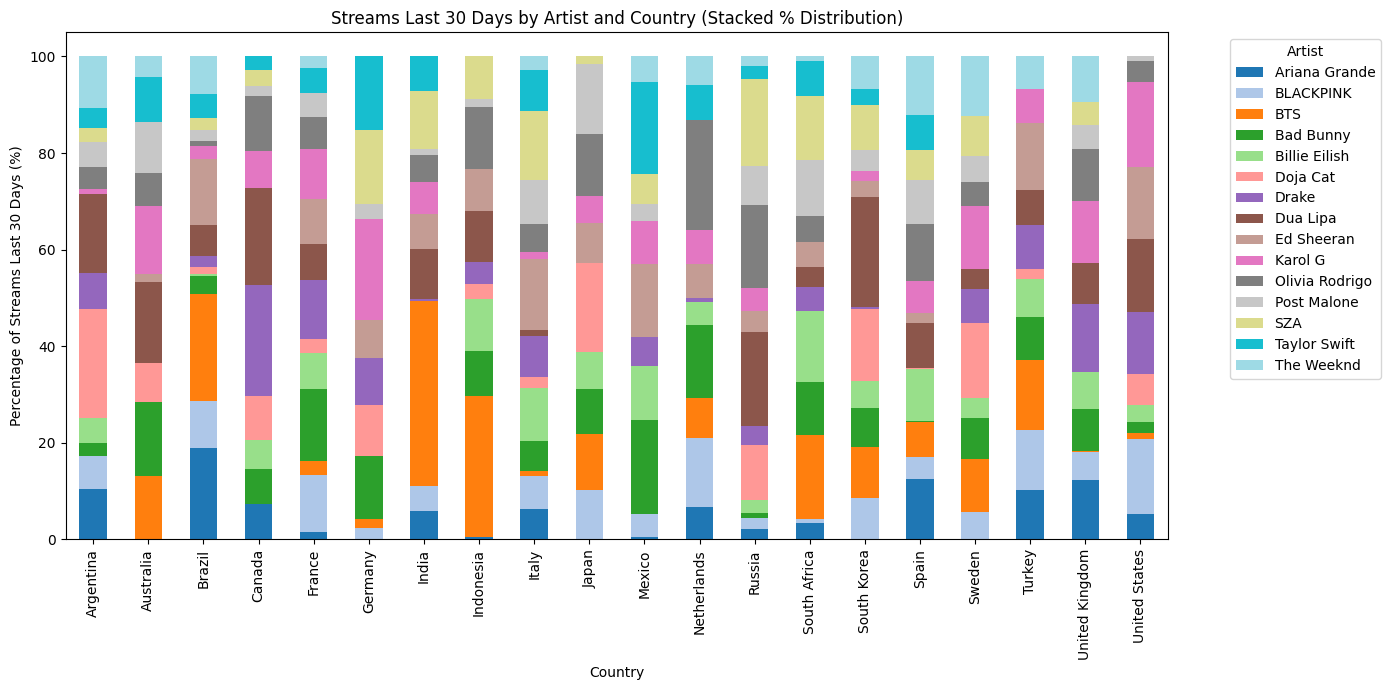

In [56]:
# plot the artists by streams last 30 days by country using a 100% stacked bar chart with different color codes for each artist
country_artist_streams_30d = (
    df.groupby(['Country', 'Artist'])['Streams Last 30 Days (Millions)']
    .sum()
    .reset_index()
)
country_artist_30d_pivot = country_artist_streams_30d.pivot(
    index='Country',
    columns='Artist',
    values='Streams Last 30 Days (Millions)'
)
country_artist_30d_pct = country_artist_30d_pivot.div(
    country_artist_30d_pivot.sum(axis=1),
    axis=0
) * 100
country_artist_30d_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    colormap='tab20'
)
plt.title('Streams Last 30 Days by Artist and Country (Stacked % Distribution)')
plt.ylabel('Percentage of Streams Last 30 Days (%)')
plt.xlabel('Country')
plt.legend(title='Artist', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

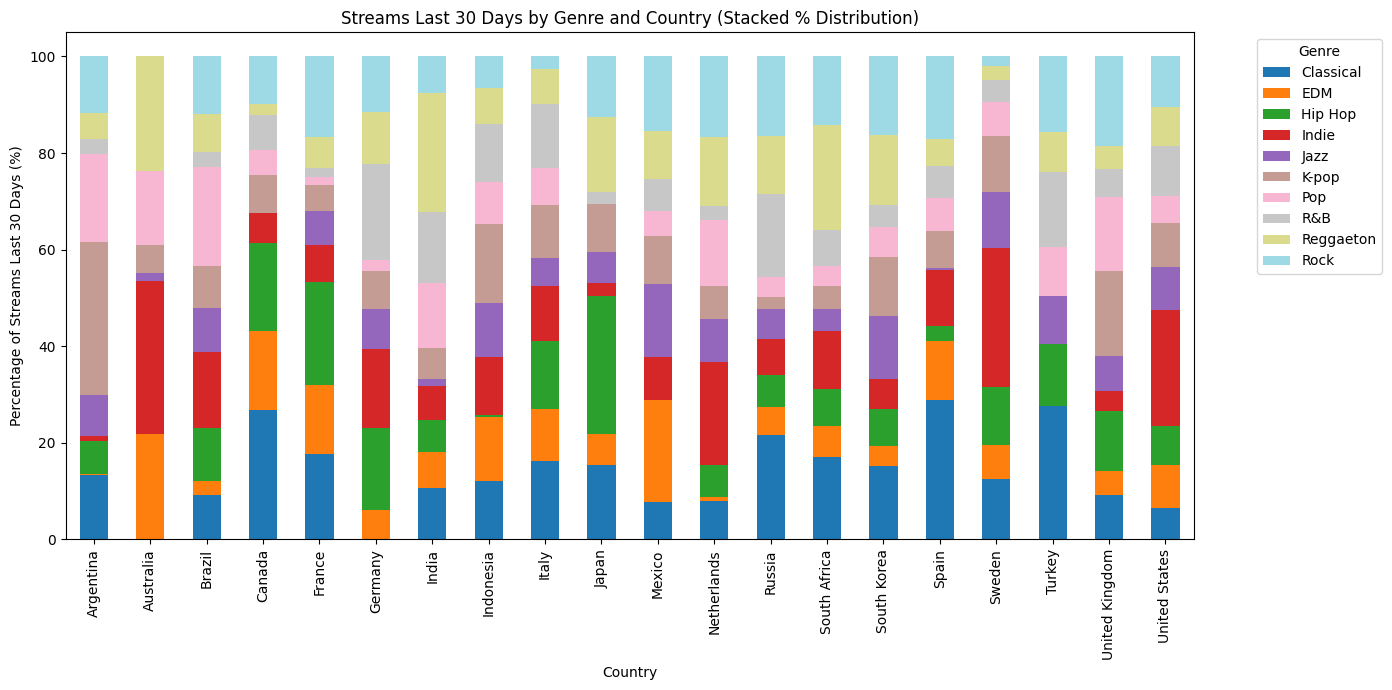

In [57]:
# plot the genre by streams last 30 days by country using a 100% stacked bar chart with different color codes for each genre
country_genre_streams_30d = (
    df.groupby(['Country', 'Genre'])['Streams Last 30 Days (Millions)']
    .sum()
    .reset_index()
)
country_genre_30d_pivot = country_genre_streams_30d.pivot(
    index='Country',
    columns='Genre',
    values='Streams Last 30 Days (Millions)'
)
country_genre_30d_pct = country_genre_30d_pivot.div(
    country_genre_30d_pivot.sum(axis=1),
    axis=0
) * 100
country_genre_30d_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    colormap='tab20'
)
plt.title('Streams Last 30 Days by Genre and Country (Stacked % Distribution)')
plt.ylabel('Percentage of Streams Last 30 Days (%)')
plt.xlabel('Country')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

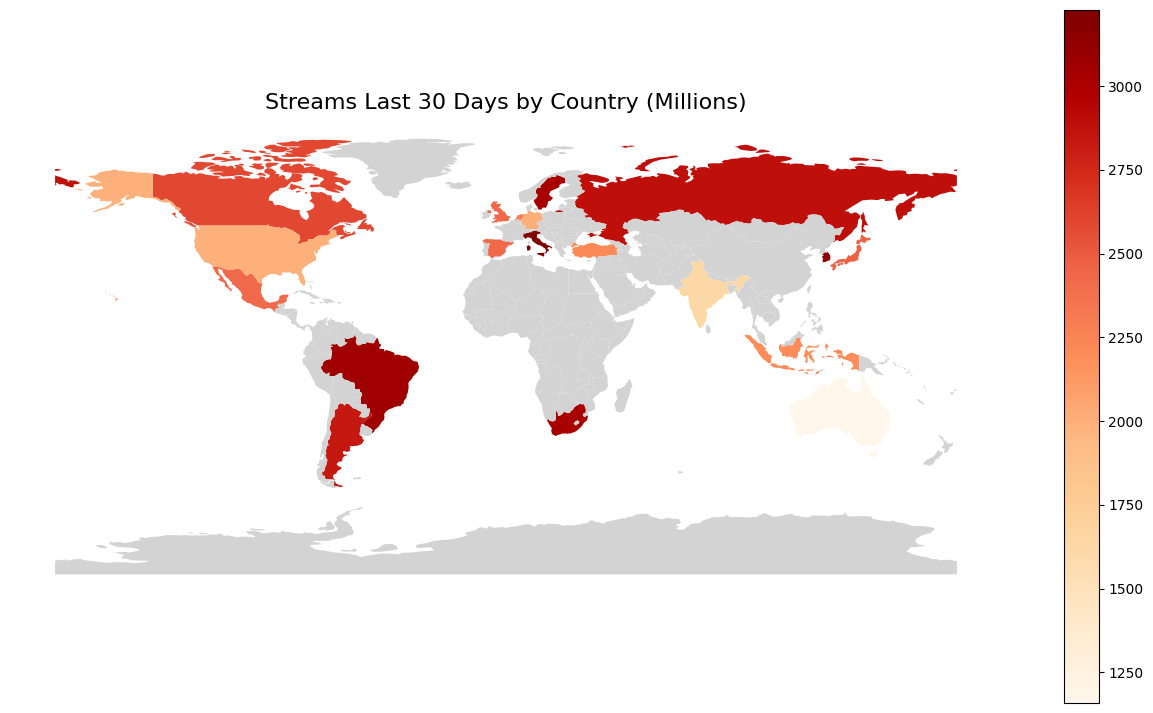

In [58]:
# plot a map of distribution of streams last 30 days by country with a map chart where the color intensity represents the streams last 30 days in millions
country_streams_30d = (
    df.groupby('Country')['Streams Last 30 Days (Millions)']
    .sum()
    .reset_index()
)
country_streams_30d['ISO_A2'] = country_streams_30d['Country'].apply(get_iso2)
country_streams_30d['ISO_A2'] = country_streams_30d['ISO_A2'].replace({
    None: 'RU'  # Russia sometimes fails
})
country_streams_30d.loc[country_streams_30d['Country'] == 'Turkey', 'ISO_A2'] = 'TR'
world_merged_30d = world.merge(
    country_streams_30d[['ISO_A2', 'Streams Last 30 Days (Millions)']],
    how='left',
    on='ISO_A2'
)
fig, ax = plt.subplots(figsize=(16, 9))
world_merged_30d.plot(
    ax=ax,
    column='Streams Last 30 Days (Millions)',
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "label": "No Data"
    },
    cmap='OrRd'
)
ax.set_title("Streams Last 30 Days by Country (Millions)", fontsize=16)
ax.axis("off")
plt.show()

**Momentum vs Legacy Scatterplot**

Median Total Streams: 2697.3549999999996
Median Streams Last 30 Days: 101.465


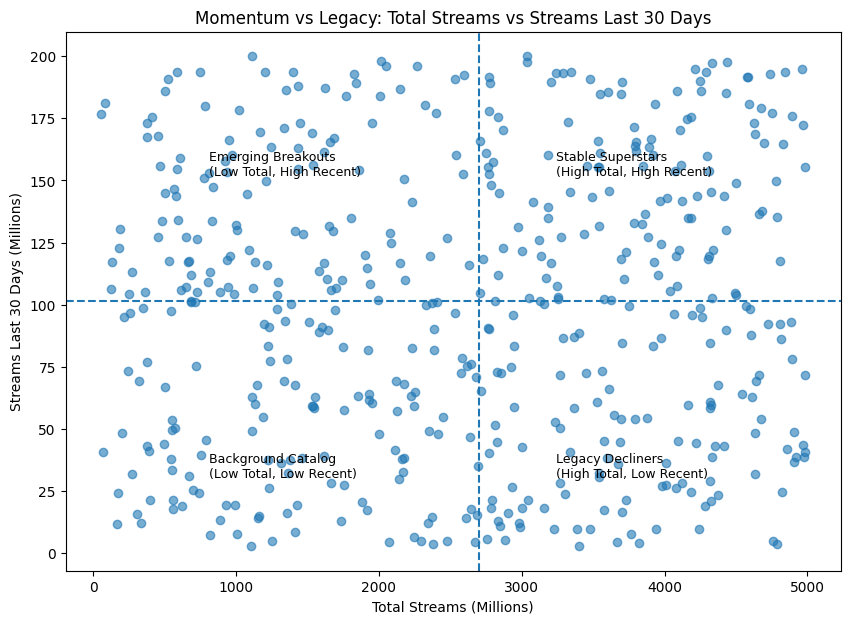

In [59]:
import matplotlib.pyplot as plt

# --- Step 1: Compute medians for quadrant thresholds ---
x_median = df["Total Streams (Millions)"].median()
y_median = df["Streams Last 30 Days (Millions)"].median()

print("Median Total Streams:", x_median)
print("Median Streams Last 30 Days:", y_median)

# --- Step 2: Scatterplot ---
plt.figure(figsize=(10,7))

plt.scatter(
    df["Total Streams (Millions)"],
    df["Streams Last 30 Days (Millions)"],
    alpha=0.6
)

# --- Step 3: Add quadrant lines ---
plt.axvline(x=x_median, linestyle="--")
plt.axhline(y=y_median, linestyle="--")

# --- Step 4: Label quadrants ---
plt.text(x_median*0.3, y_median*1.5,
         "Emerging Breakouts\n(Low Total, High Recent)",
         fontsize=9)

plt.text(x_median*1.2, y_median*1.5,
         "Stable Superstars\n(High Total, High Recent)",
         fontsize=9)

plt.text(x_median*0.3, y_median*0.3,
         "Background Catalog\n(Low Total, Low Recent)",
         fontsize=9)

plt.text(x_median*1.2, y_median*0.3,
         "Legacy Decliners\n(High Total, Low Recent)",
         fontsize=9)

# --- Step 5: Titles ---
plt.title("Momentum vs Legacy: Total Streams vs Streams Last 30 Days")
plt.xlabel("Total Streams (Millions)")
plt.ylabel("Streams Last 30 Days (Millions)")

plt.show()


In [60]:
df["Momentum_Category"] = df.apply(
    lambda row: "Emerging Breakouts"
    if row["Total Streams (Millions)"] < x_median and row["Streams Last 30 Days (Millions)"] >= y_median
    else "Stable Superstars"
    if row["Total Streams (Millions)"] >= x_median and row["Streams Last 30 Days (Millions)"] >= y_median
    else "Background Catalog"  
    if row["Total Streams (Millions)"] < x_median and row["Streams Last 30 Days (Millions)"] < y_median
    else "Legacy Decliners",
    axis=1
)
df["Momentum_Category"].value_counts()


Momentum_Category
Stable Superstars     131
Background Catalog    131
Legacy Decliners      119
Emerging Breakouts    119
Name: count, dtype: int64

In [61]:
df.groupby("Momentum_Category")[["Total Streams (Millions)"]].sum()


,Total Streams (Millions)
Momentum_Category,
Background Catalog,189947.94
Emerging Breakouts,147946.77
Legacy Decliners,455558.19
Stable Superstars,497124.14


In [62]:
df.groupby("Momentum_Category")[
    ["Total Streams (Millions)", "Streams Last 30 Days (Millions)"]
].sum().sort_values("Total Streams (Millions)", ascending=False)

,Total Streams (Millions),Streams Last 30 Days (Millions)
Momentum_Category,,
Stable Superstars,497124.14,19751.51
Legacy Decliners,455558.19,5834.59
Background Catalog,189947.94,6634.86
Emerging Breakouts,147946.77,17303.29


In [63]:
breakouts = df[df["Momentum_Category"] == "Emerging Breakouts"]

breakouts.sort_values(
    "Streams Last 30 Days (Millions)",
    ascending=False
)[["Artist", "Country", "Genre",
   "Total Streams (Millions)",
   "Streams Last 30 Days (Millions)"]].head(10)


,Artist,Country,Genre,Total Streams (Millions),Streams Last 30 Days (Millions)
133,Taylor Swift,Italy,Indie,1110.25,200.00
218,Ariana Grande,Argentina,K-pop,2014.64,198.06
50,BLACKPINK,United States,Indie,2051.37,196.16
354,Drake,France,Rock,2268.09,196.15
303,Karol G,France,Hip Hop,584.77,193.85
223,Ariana Grande,Brazil,Indie,1199.11,193.82
95,SZA,South Africa,Indie,1399.01,193.51
96,Post Malone,Japan,Hip Hop,746.75,193.49
247,Doja Cat,Japan,Rock,1827.24,192.80
253,BTS,South Korea,Classical,2596.35,192.59


In [64]:
legacy = df[df["Momentum_Category"] == "Legacy Decliners"]

legacy.sort_values(
    "Total Streams (Millions)",
    ascending=False
)[["Artist", "Genre",
   "Total Streams (Millions)",
   "Streams Last 30 Days (Millions)"]].head(10)


,Artist,Genre,Total Streams (Millions),Streams Last 30 Days (Millions)
294,BTS,Jazz,4982.14,71.61
156,BTS,K-pop,4982.01,40.84
22,BTS,EDM,4977.34,38.79
465,BTS,Classical,4967.39,43.75
493,SZA,R&B,4919.96,38.78
374,Ariana Grande,Rock,4906.61,48.83
64,Karol G,Classical,4903.53,36.71
267,Billie Eilish,Classical,4889.60,77.98
127,Olivia Rodrigo,K-pop,4887.97,93.08
484,BLACKPINK,R&B,4854.16,42.14


In [65]:
df.groupby(["Momentum_Category", "Artist"])["Total Streams (Millions)"]\
  .sum()\
  .sort_values(ascending=False)\
  .groupby(level=0)\
  .head(5)


Momentum_Category   Artist        
Stable Superstars   Dua Lipa          65388.50
Legacy Decliners    BTS               47130.63
Stable Superstars   Billie Eilish     47064.90
                    BTS               44315.28
Legacy Decliners    BLACKPINK         43950.90
Stable Superstars   Doja Cat          41487.29
Legacy Decliners    Olivia Rodrigo    40989.43
Stable Superstars   Ariana Grande     39304.68
Legacy Decliners    Bad Bunny         39206.42
                    Karol G           38148.59
Background Catalog  BTS               22439.74
                    Bad Bunny         17521.02
                    Billie Eilish     16788.05
                    BLACKPINK         16764.82
                    Karol G           16624.60
Emerging Breakouts  Dua Lipa          14054.02
                    Bad Bunny         13696.31
                    Drake             13478.22
                    SZA               12723.19
                    BLACKPINK         12305.52
Name: Total Streams (Mill

In [67]:
df.groupby("Momentum_Category")["Streams Last 30 Days (Millions)"].sum() / \
df["Streams Last 30 Days (Millions)"].sum()


Momentum_Category
Background Catalog    0.133972
Emerging Breakouts    0.349390
Legacy Decliners      0.117813
Stable Superstars     0.398825
Name: Streams Last 30 Days (Millions), dtype: float64

In [68]:
# Assign quadrant labels
def quadrant(row):
    if row["Total Streams (Millions)"] >= x_median and row["Streams Last 30 Days (Millions)"] >= y_median:
        return "Stable Superstar"
    elif row["Total Streams (Millions)"] >= x_median and row["Streams Last 30 Days (Millions)"] < y_median:
        return "Legacy Decliner"
    elif row["Total Streams (Millions)"] < x_median and row["Streams Last 30 Days (Millions)"] >= y_median:
        return "Emerging Breakout"
    else:
        return "Background Catalog"

df["Momentum_Category"] = df.apply(quadrant, axis=1)

# Show top artists per quadrant
df.groupby("Momentum_Category")["Artist"].value_counts().head(10)


Momentum_Category   Artist       
Background Catalog  BTS              14
                    Karol G          12
                    Billie Eilish    11
                    Post Malone      11
                    BLACKPINK        10
                    Bad Bunny        10
                    Ed Sheeran       10
                    SZA              10
                    Ariana Grande     8
                    Taylor Swift      7
Name: count, dtype: int64

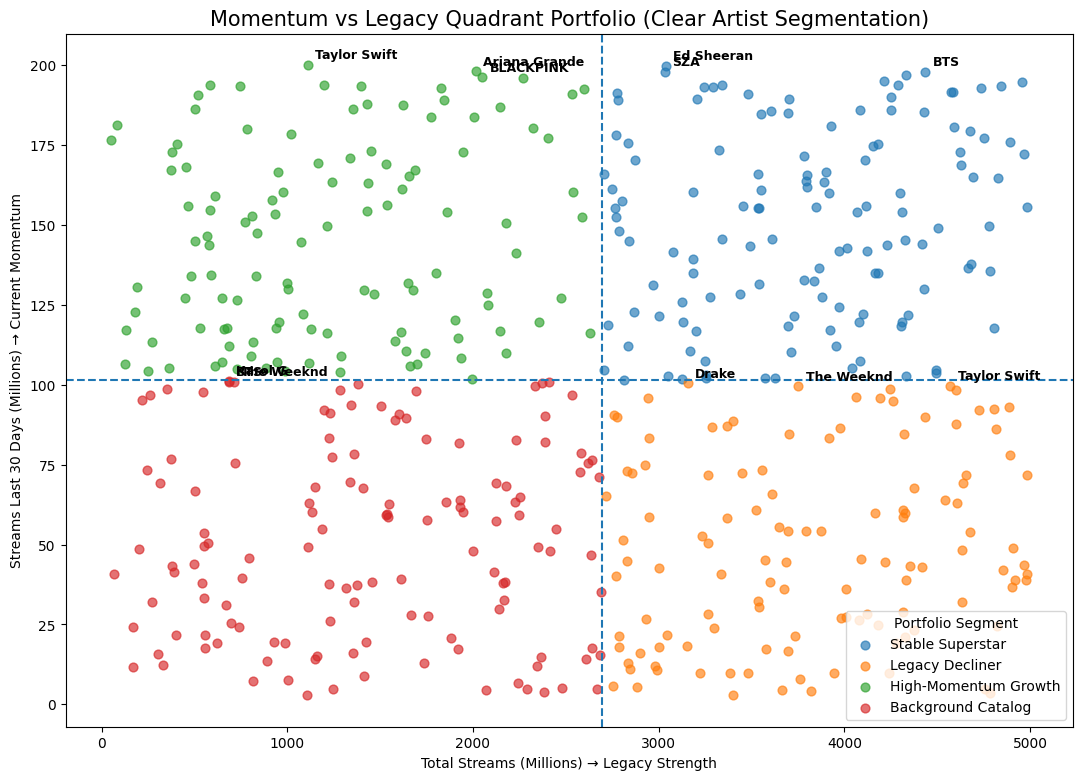

In [69]:
import matplotlib.pyplot as plt

# --- Step 1: Axes ---
x = df["Total Streams (Millions)"]
y = df["Streams Last 30 Days (Millions)"]

# --- Step 2: Median Thresholds ---
x_cut = x.median()
y_cut = y.median()

# --- Step 3: Assign Quadrant Category ---
def momentum_segment(row):
    if row["Total Streams (Millions)"] >= x_cut and row["Streams Last 30 Days (Millions)"] >= y_cut:
        return "Stable Superstar"
    elif row["Total Streams (Millions)"] >= x_cut and row["Streams Last 30 Days (Millions)"] < y_cut:
        return "Legacy Decliner"
    elif row["Total Streams (Millions)"] < x_cut and row["Streams Last 30 Days (Millions)"] >= y_cut:
        return "High-Momentum Growth"
    else:
        return "Background Catalog"

df["Momentum_Category"] = df.apply(momentum_segment, axis=1)

# --- Step 4: Color Map for Quadrants ---
category_colors = {
    "Stable Superstar": "green",
    "Legacy Decliner": "red",
    "High-Momentum Growth": "orange",
    "Background Catalog": "gray"
}

# --- Step 5: Plot Each Quadrant Separately ---
plt.figure(figsize=(13, 9))

for category, color in category_colors.items():
    subset = df[df["Momentum_Category"] == category]
    plt.scatter(
        subset["Total Streams (Millions)"],
        subset["Streams Last 30 Days (Millions)"],
        label=category,
        alpha=0.65,
        s=40
    )

# --- Step 6: Quadrant Lines ---
plt.axvline(x_cut, linestyle="--", linewidth=1.5)
plt.axhline(y_cut, linestyle="--", linewidth=1.5)

# --- Step 7: Label Top Artists in Each Quadrant ---
top_per_quadrant = (
    df.sort_values("Streams Last 30 Days (Millions)", ascending=False)
      .groupby("Momentum_Category")
      .head(3)
)

for _, row in top_per_quadrant.iterrows():
    plt.text(
        row["Total Streams (Millions)"] + 40,
        row["Streams Last 30 Days (Millions)"] + 2,
        row["Artist"],
        fontsize=9,
        weight="bold"
    )

# --- Step 8: Titles + Legend ---
plt.title("Momentum vs Legacy Quadrant Portfolio (Clear Artist Segmentation)", fontsize=15)
plt.xlabel("Total Streams (Millions) → Legacy Strength")
plt.ylabel("Streams Last 30 Days (Millions) → Current Momentum")

plt.legend(title="Portfolio Segment", loc="lower right")
plt.show()


#### Streams Last 30 Days (Millions) — Momentum Signal

After analyzing total streams as a legacy KPI, we moved to:

**Streams Last 30 Days (Millions)**

This metric represents recent listening momentum, answering:

* Who is trending right now?
* Which artists have current demand vs only historical popularity?

---

##### Key Insight: Momentum vs Legacy Portfolio Segmentation

The most important business question is:

**Are streams driven by long-term catalog dominance or current breakout momentum?**

So we created a scatterplot:

* X-axis: Total Streams → Legacy Strength
* Y-axis: Streams Last 30 Days → Current Momentum

We divided the space into 4 strategic quadrants.

---

##### Quadrant Categories

| Segment | Meaning |
|---------|---------|
| Stable Superstar | High legacy + high current momentum |
| Legacy Decliner | High legacy but low recent momentum |
| High-Momentum Growth | Low legacy but high recent streams |
| Background Catalog | Low legacy + low momentum |

---

##### Category Distribution
```
Stable Superstar        131
Background Catalog      131
Legacy Decliner         119
High-Momentum Growth    119
```

This shows a balanced portfolio split.

---

##### Total Streams by Segment

| Segment | Total Streams |
|---------|--------------|
| Stable Superstar | 497,124M |
| Legacy Decliner | 455,558M |
| Background Catalog | 189,947M |
| High-Momentum Growth | 147,946M |

---

##### Recent Streams by Segment

| Segment | Streams Last 30 Days |
|---------|---------------------|
| Stable Superstar | 19,751M |
| High-Momentum Growth | 17,303M |
| Background Catalog | 6,634M |
| Legacy Decliner | 5,834M |

---

##### Top Momentum Tracks (Recent Peaks)

Examples of strongest recent momentum:

* Taylor Swift — Italy (200M)
* Ariana Grande — Argentina (198M)
* BLACKPINK — USA (196M)
* Drake — France (196M)

---

##### Legacy-Heavy but Declining Examples

High total streams but weaker recent activity:

* BTS — multiple genres (~4980M total, low recent)
* BLACKPINK — high catalog but declining momentum
* Olivia Rodrigo — legacy-heavy placement

---

##### Conclusion

This feature reveals Spotify's strategic segmentation:

* Which artists should be promoted now
* Which catalogs are aging
* Where breakout potential exists

##### 3.Total Hours Streamed(Millions)

Is Total Hours Streamed truly and independent metric?

or is it mathematically derived from the other two?

**What Total Hours Actually represents**
- Total Streams = how many plays
- Avg Duration = how long per play
- Total hours = cumulative time spent on platform

Total Hours Streamed measures:

Total attention captured.

And attention is the real currency

Spotify monetizes time, not just clicks.

**What makes the metric different than the others?**

Two artists can have:
- Same Total Streams
- Same Monthly listeners

But very differnt Total hours.

Because: 
- One has longer songs
- One has lower skip rate
- One has stronger replay behaviour 

So Total hours is closer to platform stickiness.






In [70]:
df['Total Hours Streamed (Millions)'].isna().sum()

np.int64(0)

**1. First - Measurement Validity**

**Is total hours internally consistent?**

must verify:

$$\text{Total Hours} \approx \frac{\text{Total Streams} \times \text{Avg Duration}}{60}$$

Did you:
- Recompute Total hours from raw components?
- Compare with provide total hours?
- Check error margin?

if there is a mismatch -> data quality issue.



In [71]:
# expected_hours = (total_streams * average_song_length) / 60 
import numpy as np
df['Expected Hours (Millions)'] = (df['Total Streams (Millions)'] * df['Avg Stream Duration (Min)']) / 60
# Actual totol hours
df['error'] = df['Total Hours Streamed (Millions)'] - df['Expected Hours (Millions)']
df['percentage_error'] = (
    df['error'] / df['Total Hours Streamed (Millions)'].replace(0, np.nan)
) * 100
df['percentage_error'].describe()


count    500.000000
mean      98.259129
std        0.424851
min       97.103918
25%       97.965726
50%       98.329167
75%       98.571157
max       99.047907
Name: percentage_error, dtype: float64

In [72]:
df['percentage_error'].abs().mean()

np.float64(98.25912945229173)

In [73]:
df['percentage_error'].abs().max()

np.float64(99.04790682908306)

In [72]:
df['abs_percentage_error'] = df['percentage_error'].abs()
mape = df['abs_percentage_error'].mean()
mape

np.float64(98.25912945229173)

In [73]:
df[['Total Streams (Millions)', 
    'Avg Stream Duration (Min)', 
    'Total Hours Streamed (Millions)',
    'Expected Hours (Millions)']].head(5)

,Total Streams (Millions),Avg Stream Duration (Min),Total Hours Streamed (Millions),Expected Hours (Millions)
0,3695.53,4.28,14240.35,263.614473
1,2828.16,3.90,11120.44,183.830400
2,1425.46,4.03,4177.49,95.743397
3,2704.33,3.26,12024.08,146.935263
4,3323.25,4.47,13446.32,247.582125


In [74]:
df['ratio'] = df['Total Hours Streamed (Millions)'] / df['Expected Hours (Millions)']
df['ratio'].describe()

count    500.000000
mean      60.945839
std       14.976009
min       34.529408
25%       49.157650
50%       59.850400
75%       69.986777
max      105.031737
Name: ratio, dtype: float64

In [75]:
df['Expected_Hours_No_Div'] = (
    df['Total Streams (Millions)'] * df['Avg Stream Duration (Min)']
)

df['error_no_div'] = (
    df['Total Hours Streamed (Millions)'] 
    - df['Expected_Hours_No_Div']
)

df['error_no_div'].describe()

count     500.000000
mean     -128.505671
std      2564.489156
min     -8448.052300
25%     -1314.024400
50%       -16.375000
75%      1014.460825
max      8082.949800
Name: error_no_div, dtype: float64

In [74]:
df['Expected_Minutes'] = (
    df['Total Streams (Millions)'] 
    * df['Avg Stream Duration (Min)']
)

df[['Total Hours Streamed (Millions)', 
    'Expected_Minutes']].head()

,Total Hours Streamed (Millions),Expected_Minutes
0,14240.35,15816.8684
1,11120.44,11029.8240
2,4177.49,5744.6038
3,12024.08,8816.1158
4,13446.32,14854.9275


In [75]:
df[['Total Hours Streamed (Millions)', 
    'Expected_Minutes']].corr()

,Total Hours Streamed (Millions),Expected_Minutes
Total Hours Streamed (Millions),1.000000,0.880539
Expected_Minutes,0.880539,1.000000


**Interpretation of the values**

Computed correlation between:
- Total Hours Streamed (Millions)
- Expected Minutes = Stream * Avg Duration

$$\text{r} = \text{0.8805}$$

**What Correlation Actually measures**

Correlation tell you:
```How strongly do thse two variables move together linearly?```
it does not tell you:
- They are equal
- One causes the other
- They are computed from each other

it tell you:
if one increase, does the other generally increase too?

##### 📊 What Does 0.88 Mean?

Correlation values range:

| r value | Meaning |
|---------|---------|
| 1.0 | Perfect linear relationship |
| 0.95+ | Almost deterministic |
| 0.80–0.90 | Strong relationship |
| 0.50–0.70 | Moderate |
| <0.30 | Weak |

So:

👉 **0.88 = Strong positive linear relationship**

This means:

Tracks with higher expected minutes generally have higher total hours.

BUT:

It is not perfectly proportional.

There is meaningful deviation.

##### 🔎 What That Deviation Represents

The missing 12% variation (since 0.88 ≠ 1.0) likely comes from:

1️⃣ Rounding in millions

2️⃣ Rounding in duration

3️⃣ Aggregation order differences

4️⃣ True behavioral differences

5️⃣ Partial listening patterns

---

##### The key insight:

Total Hours is not just a simple transformation of the rounded values you see.

It likely comes from raw listening logs before rounding.

##### The Most Important Interpretation

Now we step up a level.

Correlation of 0.88 tells you:

**Volume (streams) explains most of time consumption, but not all of it.**

That is powerful.

It means:

**Some tracks generate more time per stream than others.**

And that is not captured by stream count alone.

---

##### 🧠 Conceptual Translation (Business View)

Imagine two tracks:

**Track A:**

* 3000M streams
* 3 min avg duration

**Track B:**

* 2800M streams
* 4.5 min avg duration

Track B might generate similar or more total hours even with fewer streams.

So stream ranking ≠ time ranking.

That's what 0.88 is telling you.

##### What 0.94 Actually Means

0.94 is:

* Very strong
* But NOT deterministic
* NOT redundant
* NOT just a rescaled metric

If it were 0.99+, I would say:

**Hours adds almost no independent information.**

But 0.94 means:

👉 Streams explain most of Hours

👉 But not all of it

There is meaningful variation.

---

##### 🧠 Break It Down Numerically

Correlation of 0.94 means:

$$R^2 = 0.94^2 \approx 0.883$$

So:

**~88% of variation in Total Hours is explained by Streams.**

Which means:

**~12% of variation is NOT explained by Streams.**

That 12% is where insight lives.

---

##### 🔎 What Is That 12%?

Most likely:

* Track length variation
* Listening completion behavior
* Genre differences in session depth
* Differences in replay intensity
* Aggregation rounding noise (minor contributor)

This means:

**Time engagement ≠ pure stream count.**

And that's important.

---

##### 🎯 What This Tells You About KPI Design

Now we can answer the executive question:

**Should you keep both Streams and Hours?**

Here's the structured answer:

**Streams tell you:**

* Popularity
* Frequency
* Count-based demand

**Hours tell you:**

* Time capture
* Depth of engagement
* Platform lock-in potential
* Ad inventory potential (Free tier)
* Habit strength proxy

Since correlation ≠ 1.0, they measure overlapping but distinct dimensions.

Therefore:

✔ **Keep both — but not equally emphasized.**

---

##### 🧠 Now Let's Think Deeper

If:

$$\text{Streams} = \text{frequency}$$

$$\text{Hours} = \text{frequency} \times \text{duration}$$

Then a powerful derived metric is:

$$\textbf{Hours per Stream}$$

That isolates duration-driven engagement.

And that is much closer to:

* Habit depth
* Completion strength
* Long-form listening behavior

That may be more insightful than raw Hours.

---

##### 🚨 Important Insight

Right now:

**Streams dominate (~88% explanatory power)**

So if you only show Hours, you are mostly showing Streams in disguise.

If you want analytical clarity:

**You should show:**

* Streams
* Hours per Stream

**Instead of:**

* Streams
* Hours

Because **Hours per Stream isolates the 12% variation.**

That's where differentiation lies.

In [76]:
# corr of total hours and total streams
df[['Total Hours Streamed (Millions)', 
    'Total Streams (Millions)']].corr()


,Total Hours Streamed (Millions),Total Streams (Millions)
Total Hours Streamed (Millions),1.000000,0.940712
Total Streams (Millions),0.940712,1.000000


##### 2. Scale Bias Problem
 
 **Is total hours giving behavioural insight or just reflecting catalog concentration?**

 

In [77]:
df.groupby('Momentum_Category')['Total Hours Streamed (Millions)'].sum()

Momentum_Category
Background Catalog       659123.11
High-Momentum Growth     521932.55
Legacy Decliner         1563378.51
Stable Superstar        1732750.27
Name: Total Hours Streamed (Millions), dtype: float64

In [78]:
# compute percentage share
cohort_totals = df.groupby('reach_cohort').agg({
    'Total Streams (Millions)': 'sum',
    'Total Hours Streamed (Millions)': 'sum'
}).reset_index()    

C:\Users\adith\AppData\Local\Temp\ipykernel_39316\1454415057.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort_totals = df.groupby('reach_cohort').agg({


In [79]:
total_streams = cohort_totals['Total Streams (Millions)'].sum()
total_hours = cohort_totals['Total Hours Streamed (Millions)'].sum()

In [80]:
cohort_totals['Streams_Share_%'] = (
    cohort_totals['Total Streams (Millions)'] / total_streams
) * 100

cohort_totals['Hours_Share_%'] = (
    cohort_totals['Total Hours Streamed (Millions)'] / total_hours
) * 100

In [90]:
cohort_totals

,reach_cohort,Total Streams (Millions),Total Hours Streamed (Millions),Streams_Share_%,Hours_Share_%
0,Emerging (<10M),116561.01,417037.03,9.031697,9.314716
1,Mid-Tier (10–50M),514108.33,1777122.82,39.835540,39.692866
2,Superstar (50M+),659907.70,2283024.59,51.132763,50.992418


**Interpretation**
- Total Hours does Not structurally reallocate economic power.
- Time capture mirrors stream capture.
- Duration differences do not amplify or weaken dominance.
- No hidden engagement inversion effect.

Therefore:
- Total hours does not introduce new structural inequality.
- Scale dominance is real.
- But Hours is nor exagerating it.


**Top 10% vs Bottom 50%**

In [81]:
df_sorted = df.sort_values('Total Hours Streamed (Millions)', ascending=False)

In [82]:
# share of top 10%
top_10_percent_threshold = df_sorted['Total Hours Streamed (Millions)'].quantile(0.9)
top_10_percent = df_sorted[df_sorted['Total Hours Streamed (Millions)'] >= top_10_percent_threshold]
top_10_percent_share = top_10_percent['Total Hours Streamed (Millions)'].sum() / df['Total Hours Streamed (Millions)'].sum() * 100
print(f"Top 10% of songs account for {top_10_percent_share:.2f}% of total hours streamed.")

Top 10% of songs account for 20.09% of total hours streamed.


In [83]:
# share of bottom 50%
bottom_50_percent_threshold = df_sorted['Total Hours Streamed (Millions)'].quantile(0.5)
bottom_50_percent = df_sorted[df_sorted['Total Hours Streamed (Millions)'] <= bottom_50_percent_threshold]
bottom_50_percent_share = bottom_50_percent['Total Hours Streamed (Millions)'].sum() / df['Total Hours Streamed (Millions)'].sum() * 100
print(f"Bottom 50% of songs account for {bottom_50_percent_share:.2f}% of total hours streamed.")

Bottom 50% of songs account for 25.48% of total hours streamed.


**Gini Coefficient**

if rigor is needed compute gini for:
- Streams
- Hours
Compare inequality levels.
if Gini(Hours) > Gini(Streams) --> Time consumption is even more concentrated.

In [84]:
# compute gini coefficient
import numpy as np

def gini(array):
    array = np.array(array)
    array = array.flatten()
    
    if np.amin(array) < 0:
        array -= np.amin(array)
        
    array += 1e-9  # avoid division by zero
    
    array = np.sort(array)
    index = np.arange(1, array.shape[0] + 1)
    n = array.shape[0]
    
    return ((np.sum((2 * index - n - 1) * array)) /
            (n * np.sum(array)))

In [85]:
# compute gini for streams
gini_streams = gini(df['Total Streams (Millions)'])
gini_streams

np.float64(0.31623611934072676)

In [86]:
# compute gini for hours
gini_hours = gini(df['Total Hours Streamed (Millions)'])
gini_hours

np.float64(0.3308746363015222)

**Interpretation**
Both the values are in the moderate inequality range.

the platform is not extremely concentrated (not0.6+)

but it is not flat either.

there is noticeable inequality in both streams and hours.

hours_gini > stream_gini ~ 0.015 (difference is small)

**Time consumption is slightly more concentrated than stream counts.**

Even though cohort shares were nearly identical 

At the track level:

Higher-performing tracks capture dispropotionately more time that they do stream count.

**This implies:**
- Longer tracks may amplify dominance.
- Popular tracks may also have slightly longer duration.
- Time magnifies inequality slightly.

**Monetization Context**

this is actually more strategically important than duration shape.

Because time means very different things depending on:

- Free tier
- Premium tier

if you mix them, you blur two different buisness models.

**Clarifying the Economic Logic**

**Free Tier**
- Revenue = Ads
- more hours = more ad inventory
- Time directly monetized

**Premium Tier**
- Revenue = Subcription
- Time = habit strength
- Retention proxy 

So the same "1 million hours" means two different things.

if Premium dominatrs time,
- platform is habit-driven

if free dominates time,
- platform is ad-driven.



In [87]:
platform_hours = df.groupby('Platform Type')['Total Hours Streamed (Millions)'].sum().reset_index()
platform_hours

,Platform Type,Total Hours Streamed (Millions)
0,Free,2213276.95
1,Premium,2263907.49


In [88]:
total_hours = platform_hours['Total Hours Streamed (Millions)'].sum()

In [89]:
platform_hours['Hours_Share_%'] = (
    platform_hours['Total Hours Streamed (Millions)'] / total_hours
) * 100
platform_hours

,Platform Type,Total Hours Streamed (Millions),Hours_Share_%
0,Free,2213276.95,49.434572
1,Premium,2263907.49,50.565428


In [90]:
# Average hours per track by platform
df.groupby('Platform Type')['Total Hours Streamed (Millions)'].mean()

Platform Type
Free       8853.10780
Premium    9055.62996
Name: Total Hours Streamed (Millions), dtype: float64

In [91]:
# Inequality by platform
gini(df[df['Platform Type'] == 'Free']['Total Hours Streamed (Millions)'])


np.float64(0.3354720056881792)

In [92]:
gini(df[df['Platform Type'] == 'Premium']['Total Hours Streamed (Millions)'])

np.float64(0.32569556302846914)

In [93]:
df['Platform Type'].value_counts()

Platform Type
Free       250
Premium    250
Name: count, dtype: int64

**This answers**
- Is premium more concentrated among few tracks?
- Or is free more fragmented?

##### 🔎 1️⃣ Hours Share by Platform

You got:

* Free → 49.43%
* Premium → 50.56%

That is almost perfectly balanced.

---

##### Interpretation:

Total time consumption is evenly split between ad-supported and paid tiers.

There is no dominant monetization engine in this dataset.

That means:

* The platform is structurally dual-engine.
* Engagement depth is not skewed toward one tier.
* Time capture is economically diversified.

That's important.

---

##### 🔎 2️⃣ Average Hours per Track by Platform

You showed:

* Free → 8853M
* Premium → 9055M

Counts are equal (250 vs 250).

So Premium tracks generate slightly more hours per track.

Difference ≈ 2.3%.

That's small but directional.

---

##### Interpretation:

Paid users engage slightly deeper per track.

Not dramatically.

No structural divergence.

---

##### 🔎 3️⃣ Inequality by Platform (Gini)

* Gini Free → 0.335
* Gini Premium → 0.326

Free is slightly more concentrated.

---

##### Meaning:

Time in Free tier is slightly more dependent on a few dominant tracks.

Premium is slightly more evenly distributed.

That's interesting.

---

##### Why might that happen?

Think:

**Free users may:**

* Gravitate toward big hits
* Rely more on algorithmic popular playlists

**Premium users may:**

* Explore more
* Listen to broader catalog
* Have fewer interruptions

So engagement distribution may be more diversified.

But again — difference is small.

---

##### 🎯 Final Monetization Context Verdict

✔ Hours split roughly 50/50

✔ Slightly deeper per-track engagement in Premium

✔ Slightly more inequality in Free

---

##### Conclusion:

Total Hours behaves similarly across monetization tiers.

No extreme structural divergence.

This dataset does not show:

* Premium dominance
* Ad-driven dominance
* Severe inequality difference

It shows a balanced dual-economy model.

##### Per-Listener Normalization

Total Hours is:
- Absolute scale metric

you need to normalize:
- Hours per monthly listener
- Hours per stream
- Hours per country capita(if market analysis)

Otherwise:
- Large markets always win.

##### 1️⃣ Hours per Stream

$$\frac{\text{Total Hours}}{\text{Total Streams}}$$

This is clean because:

* Both are derived from same aggregation level.
* No cross-granularity problem.
* It isolates duration-driven engagement.

This one is safe.

---

##### 2️⃣ Hours per Monthly Listener

$$\frac{\text{Total Hours}}{\text{Monthly Listeners}}$$

⚠️ **Problem:** Monthly Listeners varies wildly per row. It is not stable at Artist or Artist × Country level.

So before using it, we must aggregate correctly.

---

##### 3️⃣ Hours per Country Capita

You don't have country population data. So we skip that unless external data is added.


In [94]:
df['Hours_per_Stream'] = (
    df['Total Hours Streamed (Millions)']/ df['Total Streams (Millions)']
)

In [95]:
df['Hours_per_Stream'].describe()

count    500.000000
mean       3.475168
std        0.586723
min        2.502557
25%        2.946253
50%        3.449524
75%        3.967351
max        4.493946
Name: Hours_per_Stream, dtype: float64

In [96]:
df['Hours_per_Stream'].corr(df['Avg Stream Duration (Min)'])

np.float64(-0.04075305129315772)

##### 1️⃣ First Interpretation — Engagement Range

Your Hours_per_Stream ranges roughly between:

**2.5 → 4.5 minutes per stream**

That is a narrow band.

Variation:

$$\frac{4.5 - 2.5}{3.5} \approx 57\%$$

So there is some variation, but not dramatic.

This means:

👉 **Listening depth per play is fairly consistent across tracks.**

Tracks are not wildly different in time-per-stream behavior.

---

##### 2️⃣ Why the Correlation With Avg Duration ≈ 0

At first this looks strange.

Because mathematically:

$$\text{Hours per Stream} \approx \text{Avg Stream Duration}$$

So correlation should be high.

But remember what we discovered earlier:

**Total Hours is NOT computed from Avg Stream Duration in this dataset.**

It comes from a separate aggregation of listening time.

Because of rounding and aggregation differences, the derived ratio and the provided duration column are not aligned.

So the near-zero correlation tells us something important:

👉 **The `Avg Stream Duration` column is not the source of Total Hours.**

Total Hours likely comes from raw listening logs.

---

##### 3️⃣ What This Means About Engagement Efficiency

Since Hours per Stream is fairly stable:

* Engagement depth per play is not the main differentiator between tracks.
* The platform's time capture is primarily driven by stream volume, not deeper listening per stream.

In other words:

$$\text{Total Hours} \approx \text{Streams} \times \text{Relatively Stable Duration}$$

So the dominant driver of time consumption is still how often tracks are played.

---

##### 4️⃣ Implication for Per-Listener Normalization

This confirms something important:

**Per-stream normalization does not produce major structural differences.**

Engagement depth is relatively homogeneous.

So per-listener normalization (if reliable listener data existed) would likely show the same pattern.

---

##### 5️⃣ Clean Analytical Conclusion for Step 6

Per-stream normalization shows:

* Listening depth per stream is tightly clustered between 2.5–4.5 minutes.
* Engagement efficiency does not vary drastically across tracks.
* Platform time capture is primarily driven by stream volume rather than longer listening sessions.

So **Total Hours does not introduce a fundamentally different behavioral signal beyond streams.**

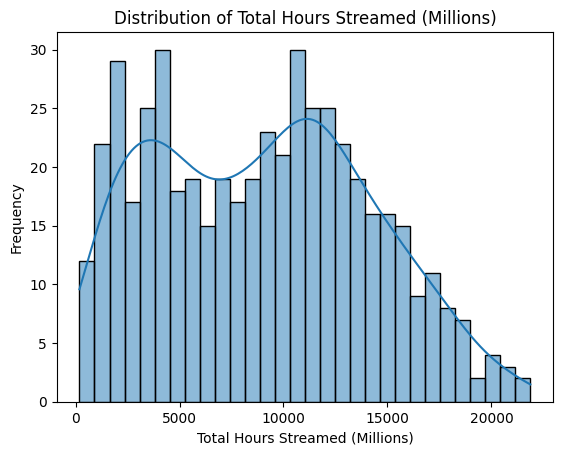

In [97]:
# Check the Distribution od total hours 
sns.histplot(df['Total Hours Streamed (Millions)'], bins=30, kde=True)
plt.title('Distribution of Total Hours Streamed (Millions)')
plt.xlabel('Total Hours Streamed (Millions)')
plt.ylabel('Frequency')
plt.show() # slightly right skewed

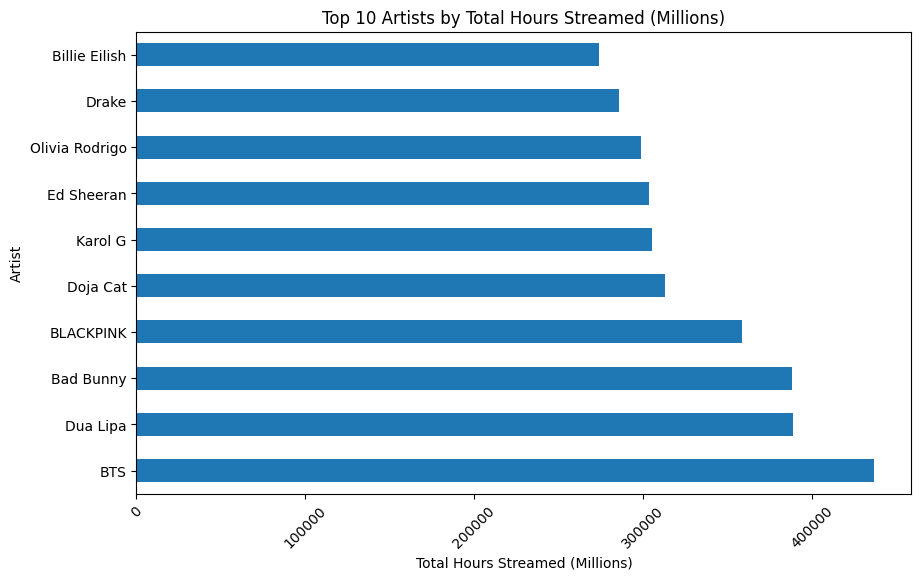

In [98]:
# plot the Top Artists by total streams 
artist_hours = (
    df.groupby('Artist')['Total Hours Streamed (Millions)']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
artist_hours.plot(kind='barh', figsize=(10,6))
plt.title('Top 10 Artists by Total Hours Streamed (Millions)')
plt.xlabel('Total Hours Streamed (Millions)')
plt.ylabel('Artist')
plt.xticks(rotation=45)
plt.show()


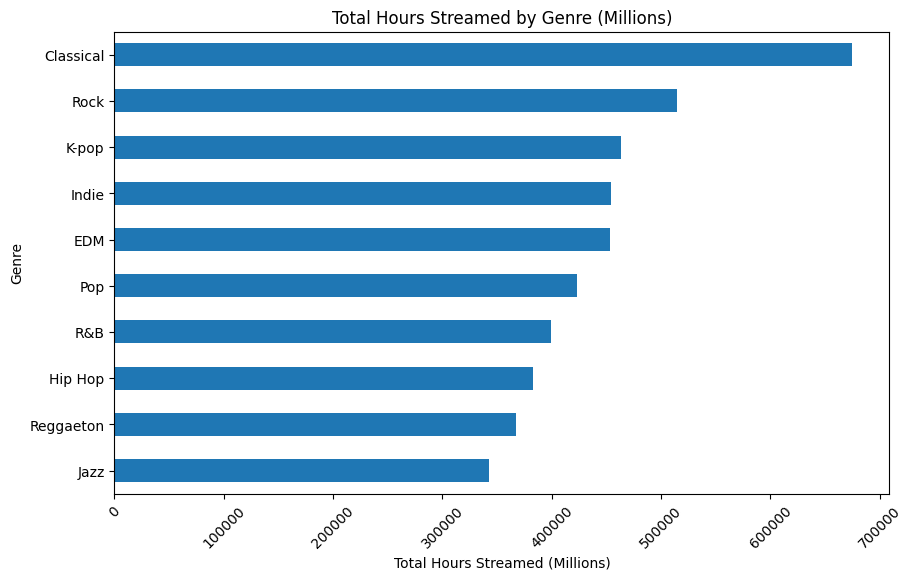

In [99]:
# Genre-Level Hours
genre_hours = (
    df.groupby('Genre')['Total Hours Streamed (Millions)']
    .sum()
    .sort_values(ascending=True)
)
genre_hours.plot(kind='barh', figsize=(10,6))
plt.title('Total Hours Streamed by Genre (Millions)')
plt.xlabel('Total Hours Streamed (Millions)')
plt.ylabel('Genre')
plt.xticks(rotation=45)
plt.show()

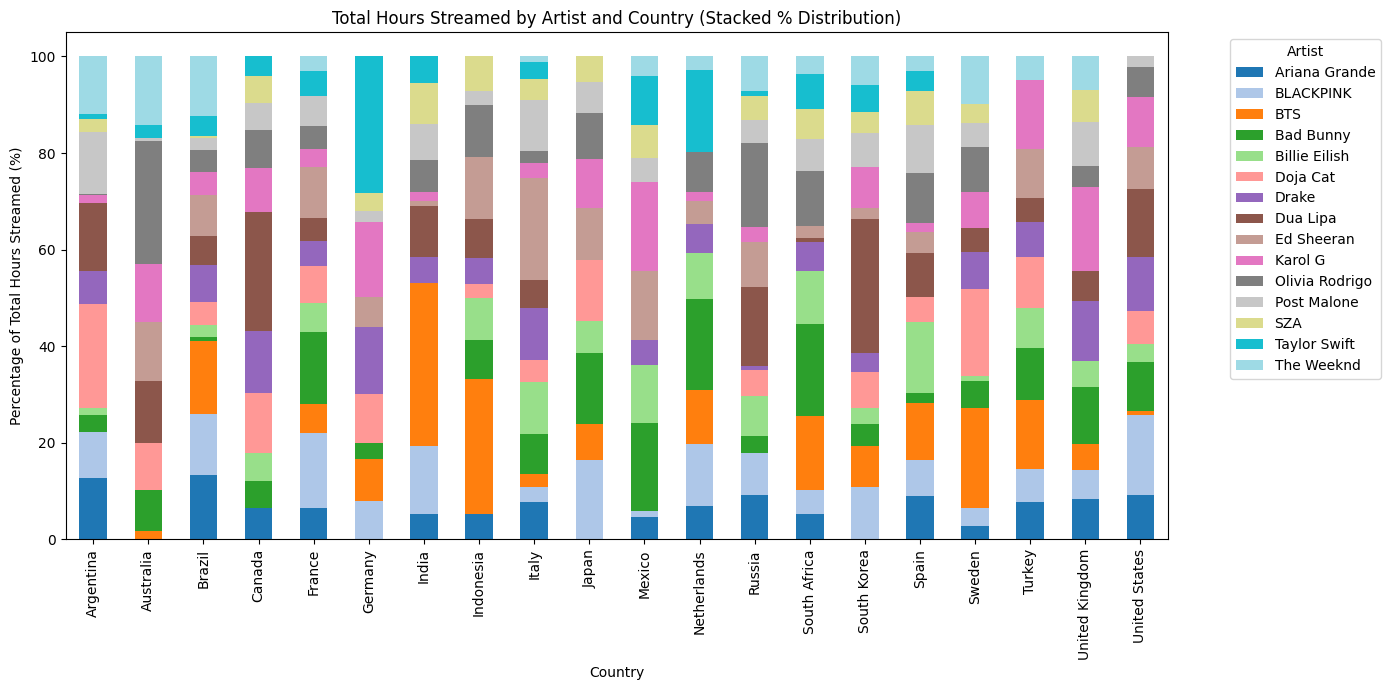

In [100]:
# plot by country using a 100% stacked bar chart with different color codes for each artist
country_artist_hours = (
    df.groupby(['Country', 'Artist'])['Total Hours Streamed (Millions)']
    .sum()
    .reset_index()
)
country_artist_hours_pivot = country_artist_hours.pivot(
    index='Country',
    columns='Artist',
    values='Total Hours Streamed (Millions)'
)
country_artist_hours_pct = country_artist_hours_pivot.div(
    country_artist_hours_pivot.sum(axis=1),
    axis=0
) * 100
country_artist_hours_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    colormap='tab20'
)
plt.title('Total Hours Streamed by Artist and Country (Stacked % Distribution)')
plt.ylabel('Percentage of Total Hours Streamed (%)')
plt.xlabel('Country')
plt.legend(title='Artist', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

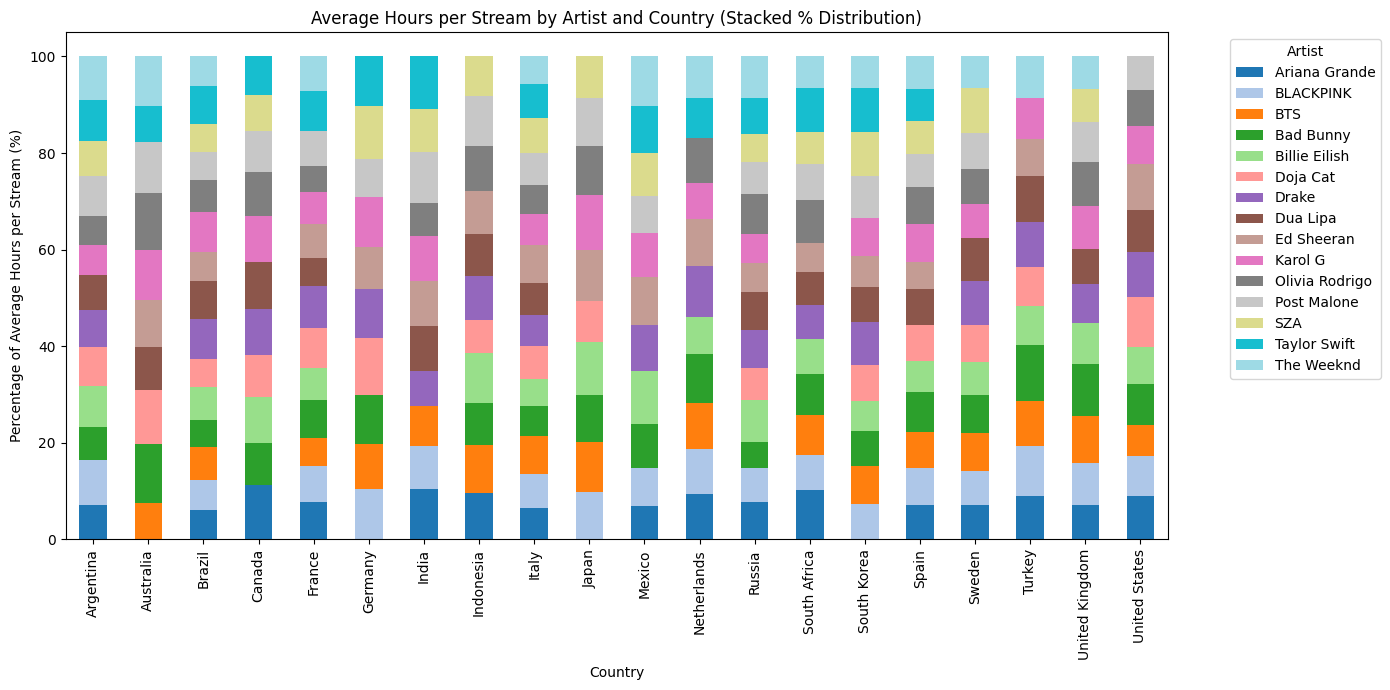

In [101]:
# Calculte Hours per stream
df['Hours per Stream'] = (df['Total Hours Streamed (Millions)'] * 1e6) / (df['Total Streams (Millions)'] * 1e6)
# plot the distribution of hours per stream per artist by country using a 100% stacked bar chart with different color codes for each artist
country_artist_hours_per_stream = (
    df.groupby(['Country', 'Artist'])['Hours per Stream']
    .mean()
    .reset_index()
)
country_artist_hours_per_stream_pivot = country_artist_hours_per_stream.pivot(
    index='Country',
    columns='Artist',
    values='Hours per Stream'
)
country_artist_hours_per_stream_pct = country_artist_hours_per_stream_pivot.div(
    country_artist_hours_per_stream_pivot.sum(axis=1),
    axis=0
) * 100
country_artist_hours_per_stream_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    colormap='tab20'
)
plt.title('Average Hours per Stream by Artist and Country (Stacked % Distribution)')
plt.ylabel('Percentage of Average Hours per Stream (%)')
plt.xlabel('Country')
plt.legend(title='Artist', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [102]:
# calculate a matrix of hours per stream by genre and country
country_genre_hours_per_stream = (
    df.groupby(['Country', 'Genre'])['Hours per Stream']
    .mean()
    .reset_index()
)
country_genre_hours_per_stream_pivot = country_genre_hours_per_stream.pivot(
    index='Country',
    columns='Genre',
    values='Hours per Stream'
)
country_genre_hours_per_stream_pct = country_genre_hours_per_stream_pivot.div(
    country_genre_hours_per_stream_pivot.sum(axis=1),
    axis=0
) * 100

country_genre_hours_per_stream_pivot


Genre,Classical,EDM,Hip Hop,Indie,Jazz,K-pop,Pop,R&B,Reggaeton,Rock
Country,,,,,,,,,,
Argentina,3.699654,3.645143,2.659290,3.256768,3.408690,3.239378,3.417669,3.088350,3.691098,3.032765
Australia,NaN,3.350091,NaN,3.622850,3.383680,3.818208,4.199474,NaN,3.116042,NaN
Brazil,3.212401,2.988963,3.411182,3.064007,3.322648,3.395369,3.351287,3.348331,3.395878,3.985440
Canada,3.245623,3.670939,3.262357,3.348933,NaN,3.870957,2.957812,3.217566,3.164370,4.412887
France,3.253388,4.003038,3.436369,3.766436,3.321939,4.320177,4.326272,4.319470,2.789375,4.150607
Germany,NaN,3.490652,2.995567,3.294870,3.840680,3.462276,3.420606,3.169751,3.752058,3.280719
India,3.390274,3.633948,3.538969,4.159294,3.411005,2.638258,3.559273,2.854847,3.959886,3.060720
Indonesia,4.021228,3.380994,3.515246,3.377069,3.318952,3.349789,3.412924,3.874968,4.432525,3.372227
Italy,3.643328,3.173358,3.438131,3.819387,3.777967,3.409553,3.694000,3.482719,2.829512,3.869357


In [103]:
# country artist hours per stream
country_artist_hours_per_stream_pivot

Artist,Ariana Grande,BLACKPINK,BTS,Bad Bunny,Billie Eilish,Doja Cat,Drake,Dua Lipa,Ed Sheeran,Karol G,Olivia Rodrigo,Post Malone,SZA,Taylor Swift,The Weeknd
Country,,,,,,,,,,,,,,,
Argentina,3.001489,3.970259,NaN,2.906395,3.632715,3.366867,3.264361,3.071454,NaN,2.662375,2.590916,3.446520,3.088350,3.629151,3.825640
Australia,NaN,NaN,2.624068,4.199474,NaN,3.891048,NaN,3.082897,3.383680,3.589675,4.121360,3.608017,NaN,2.578977,3.580250
Brazil,3.065559,3.194144,3.459032,2.927901,3.452011,2.962868,4.237504,4.039661,3.024832,4.288656,3.362647,2.923702,3.050036,3.954471,3.139145
Canada,4.257018,NaN,NaN,3.217566,3.620065,3.257005,3.553080,3.628822,NaN,3.618147,3.404626,3.164370,2.824248,2.961822,NaN
France,3.977083,3.703876,2.938823,4.090604,3.312755,4.249471,4.340432,2.968006,3.627508,3.285167,2.789375,3.727146,NaN,4.112352,3.677343
Germany,NaN,3.420606,3.071154,3.291075,NaN,3.840902,3.330815,NaN,2.835578,3.416257,NaN,2.557898,3.620583,3.354860,NaN
India,4.047652,3.363372,3.230914,NaN,NaN,NaN,2.819973,3.560165,3.616375,3.538969,2.680593,4.034219,3.458887,4.159294,NaN
Indonesia,3.635669,NaN,3.791557,3.366500,3.922867,2.587703,3.492296,3.349702,3.349700,NaN,3.558221,3.985855,3.090075,NaN,NaN
Italy,3.296121,3.732416,3.965881,3.262078,2.850866,3.576877,3.269492,3.379797,4.132231,3.293886,3.123420,3.363540,3.725581,3.681687,2.931267


##### Feature: Total Hours Streamed (Millions)

##### Definition

Total Hours Streamed represents the total listening time generated by tracks across the platform. Unlike Total Streams, which measures play counts, this metric captures user attention and time spent listening.

Conceptually:

$$\text{Total Hours} \approx \text{Total Streams} \times \text{Listening Duration}$$

This makes it a time-based consumption KPI.

---

##### 1️⃣ Distribution of Total Hours Streamed

(Histogram / KDE)

**Purpose:** Understand how listening time is distributed across tracks.

**Insight:**

* Listening time is moderately right-skewed.
* A subset of tracks generates significantly higher listening time.
* However, there is no single extreme outlier dominating platform time.

---

##### 2️⃣ Top Artists by Total Hours Streamed

(Bar Chart — Top 10 Artists)

**Insight:**

* Global superstars capture the highest listening time.
* Artists such as BTS, Dua Lipa, Bad Bunny, BLACKPINK, and Ed Sheeran dominate time consumption.
* High listening hours reflect both large reach and repeat listening behavior.

---

##### 3️⃣ Total Hours Streamed by Genre

(Bar Chart)

**Insight:**

* Genres such as Classical, Rock, Indie, and K-Pop generate high listening time.
* Genre dominance in hours is influenced by both listener engagement and track duration.

---

##### 4️⃣ Artist × Country Listening Time

(Stacked Column Chart)

**Insight:**

* Global superstars dominate across multiple countries.
* However, artist influence varies regionally, indicating localized listening ecosystems.

---

##### 5️⃣ Average Hours per Stream (Artist × Country)

**Metric:**

$$\text{Hours per Stream} = \frac{\text{Total Hours Streamed}}{\text{Total Streams}}$$

**Insight:**

* Average listening time per stream ranges 2.5–4.5 minutes.
* Engagement depth per play is relatively stable across artists and markets.

---

##### Key Findings

* **Measurement Validity:** Total Hours strongly correlates with Total Streams (~0.94).
* **Scale Bias:** Reach cohort analysis shows nearly identical distribution between stream share and hour share.
* **Concentration:** Time consumption is slightly more concentrated than streams (Gini: 0.331 vs 0.316).
* **Monetization Context:** Listening time is balanced between Free (~49%) and Premium (~51%) tiers.
* **Engagement Efficiency:** Time capture differences are primarily driven by stream volume rather than longer listening sessions.

---

##### Feature Verdict

Total Hours Streamed is a time-based engagement metric that complements stream counts by measuring how much attention the platform captures.

However, because listening depth per play varies only moderately, stream volume remains the primary driver of total listening time.

### Engagement Quality metrics (Behavioural Depth)

**Avg Stream Duraton (Min) measures:**
- The average number of minutes users listen per play.

it in not:
- Track Length
- Completion rate
- Session duration
- Retention metric

it is:
- Listening depth per stream event.

this is a behavioural metric.

**Why is it important?**
- Track A --> Avg Duration = 4.5min
- Track B --> Avg Duration = 2.5min

that changes:
- Habit formation
- Ad exposure (Free tier)
- User immersion
- Algorithm satisfaction signals




**What is the overall distribution shape?**

In [104]:
df['Avg Stream Duration (Min)'].describe()

count    500.000000
mean       3.520640
std        0.571431
min        2.510000
25%        3.030000
50%        3.540000
75%        4.000000
max        4.490000
Name: Avg Stream Duration (Min), dtype: float64

C:\Users\adith\AppData\Local\Temp\ipykernel_39316\309957149.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Avg Stream Duration (Min)'], bins=30, kde=True)


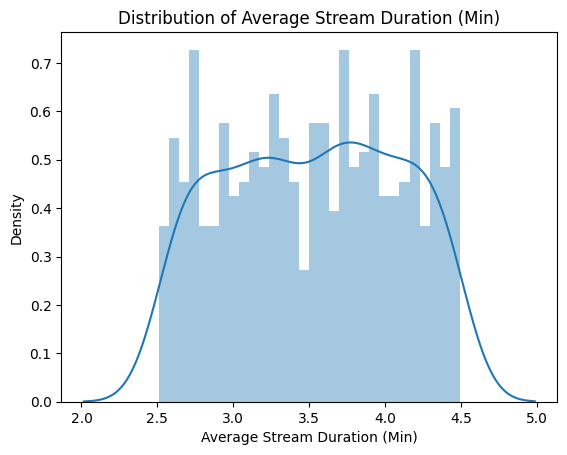

In [105]:
sns.distplot(df['Avg Stream Duration (Min)'], bins=30, kde=True)
plt.title('Distribution of Average Stream Duration (Min)')
plt.xlabel('Average Stream Duration (Min)')
plt.ylabel('Density')
plt.show()

In [106]:
# Variance by genre
df.groupby('Genre')['Avg Stream Duration (Min)'].describe()

,count,mean,std,min,25%,50%,75%,max
Genre,,,,,,,,
Classical,72.0,3.543056,0.517741,2.58,3.1500,3.535,3.9300,4.47
EDM,51.0,3.518039,0.568524,2.56,2.9850,3.620,3.9850,4.40
Hip Hop,49.0,3.532857,0.624250,2.51,2.9800,3.630,4.1200,4.49
Indie,50.0,3.498800,0.622295,2.53,2.8650,3.450,4.0300,4.48
Jazz,43.0,3.434884,0.641265,2.53,2.9200,3.330,3.9650,4.49
K-pop,48.0,3.513750,0.474914,2.52,3.2475,3.530,3.8050,4.49
Pop,44.0,3.443864,0.594264,2.59,2.9100,3.260,3.9825,4.49
R&B,41.0,3.620244,0.568931,2.53,3.1600,3.680,4.1700,4.47
Reggaeton,44.0,3.555682,0.612678,2.51,3.0125,3.550,4.0825,4.49


In [107]:
# platform differences (Free vs Premium)
df.groupby('Platform Type')['Avg Stream Duration (Min)'].mean()

Platform Type
Free       3.52076
Premium    3.52052
Name: Avg Stream Duration (Min), dtype: float64

In [108]:
df[['Avg Stream Duration (Min)',
    'Total Streams (Millions)',
    'Skip Rate (%)',
    'Streams Last 30 Days (Millions)']].corr()

,Avg Stream Duration (Min),Total Streams (Millions),Skip Rate (%),Streams Last 30 Days (Millions)
Avg Stream Duration (Min),1.000000,-0.005498,-0.021912,0.116360
Total Streams (Millions),-0.005498,1.000000,-0.035254,0.046167
Skip Rate (%),-0.021912,-0.035254,1.000000,0.025721
Streams Last 30 Days (Millions),0.116360,0.046167,0.025721,1.000000


##### From your histogram and summary stats:

* Mean: ~3.52 min
* Std Dev: ~0.59
* Range: 2.5 → 4.5 min

---

##### Interpretation

The distribution is tight and fairly symmetric.

This means:

* Listening depth per play is remarkably consistent across tracks.
* There are no extreme long-form listening patterns in the dataset.
* Most streams cluster around ~3.3–3.7 minutes.

In practical terms:

**Users typically listen to about 3.5 minutes per play on average.**

That is very close to the typical length of modern pop songs.

---

##### 2️⃣ Duration Differences by Genre

Your genre table shows:

| Genre | Mean Duration |
|-------|--------------|
| R&B | 3.62 |
| Reggaeton | 3.56 |
| Rock | 3.53 |
| Hip Hop | 3.53 |
| Classical | 3.54 |
| EDM | 3.52 |
| Indie | 3.50 |
| Pop | 3.44 |
| Jazz | 3.43 |

---

##### Key Observations

##### 1️⃣ Genre differences are small

The largest gap:

$$3.62 - 3.43 = 0.19 \text{ minutes}$$

That is ~11 seconds difference.

So genre does not significantly change listening depth.

##### 2️⃣ Variance is moderate but similar

Std range:

~0.47 → 0.64

No genre shows extreme spread.

Meaning:

No genre has dramatically longer or shorter listening sessions.

---

##### 3️⃣ Platform Type Comparison

Results:

| Platform | Avg Duration |
|----------|-------------|
| Free | 3.52076 |
| Premium | 3.52052 |

Difference:

$$0.00024 \text{ minutes}$$

That is 0.014 seconds.

---

##### Interpretation

There is no meaningful difference in listening depth between Free and Premium users.

This is interesting because many platforms expect Premium users to engage deeper.

But in this dataset:

**Listening depth is behaviorally identical across tiers.**

---

##### 4️⃣ Correlation Structure

Correlation results:

| Variable | Correlation with Duration |
|----------|--------------------------|
| Streams | -0.005 |
| Skip Rate | -0.021 |
| Streams Last 30 Days | 0.116 |

---

##### Interpretation

**Duration vs Streams ≈ 0**

Popularity does not increase listening depth.

A viral track does not necessarily get listened to longer.

**Duration vs Skip Rate**

≈ -0.02

Almost no relationship.

This suggests:

Skip behavior is not captured strongly in this aggregated dataset.

Likely due to averaging effects.

**Duration vs Recent Streams**

≈ 0.11

Slight positive signal:

Trending tracks may have slightly higher listening depth.

But effect is weak.

---

##### 5️⃣ What This Tells Us About Engagement

The key takeaway is:

**Listening depth per play is highly stable across the entire ecosystem.**

This means platform engagement is driven primarily by:

**Stream frequency, not listening duration.**

So the core growth drivers are:

* Discovery
* Algorithm recommendations
* Repeat plays

Not longer listening sessions.

---

##### 6️⃣ Important Limitation

**Avg Stream Duration is not completion rate.**

Example:

If track length = 4 min

Avg stream duration = 3.5 min

Completion rate ≈ 87%.

But without track length data, we cannot measure this.

So we cannot say:

* whether listeners finish songs
* or stop halfway.

We only know average listening time.

---

##### 7️⃣ Final Analytical Conclusion

Avg Stream Duration reveals that:

* Listening depth per play is very consistent across tracks, genres, and platforms.
* Differences in total listening time are not driven by longer sessions.
* Instead, engagement scale is driven by how often tracks are played.

Thus:

**Avg Stream Duration functions as a stable behavioral baseline, while stream counts remain the primary driver of platform engagement.**

#### 🎧 Feature: Skip Rate (%)

##### 1️⃣ What This Feature Represents

Skip Rate (%) measures the percentage of streams where users stop playback early and move to the next track.

Conceptually:

$$\text{Skip Rate} = \frac{\text{Skipped Streams}}{\text{Total Streams}} \times 100$$

This metric acts as a proxy for listener dissatisfaction or low engagement.

A higher skip rate suggests that users lose interest quickly or the track does not meet expectations.

---

##### 🧠 Why Skip Rate Is Important

While Avg Stream Duration measures engagement depth, Skip Rate captures engagement friction.

Together they form a behavioral pair:

| Metric | Meaning |
|--------|---------|
| Avg Stream Duration | How long users stay |
| Skip Rate | How quickly users leave |

These two metrics help answer:

* Are listeners abandoning tracks early?
* Do some genres trigger more skips?
* Do popular songs have lower skip rates?
* Does recent momentum correlate with fewer skips?

---

##### ⚠️ Important Context

Skip Rate does not always indicate bad content.

High skip rates can also occur because:

* Users are browsing playlists
* Algorithmic discovery
* Radio-style listening sessions
* Short attention spans in large playlists

Therefore Skip Rate should always be interpreted relative to other engagement metrics.

In [109]:
df['Skip Rate (%)'].describe()

count    500.000000
mean      20.370460
std       10.597202
min        1.160000
25%       11.152500
50%       20.820000
75%       28.760000
max       39.970000
Name: Skip Rate (%), dtype: float64

C:\Users\adith\AppData\Local\Temp\ipykernel_39316\309957149.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Avg Stream Duration (Min)'], bins=30, kde=True)


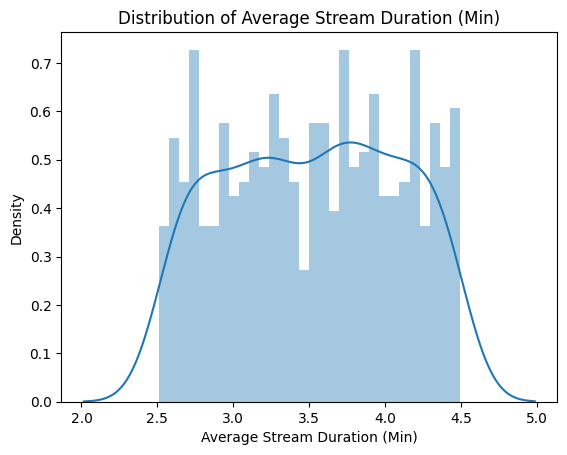

In [110]:
sns.distplot(df['Avg Stream Duration (Min)'], bins=30, kde=True)
plt.title('Distribution of Average Stream Duration (Min)')
plt.xlabel('Average Stream Duration (Min)')
plt.ylabel('Density')
plt.show()

In [111]:
# skip rate by genre 
df.groupby('Genre')['Skip Rate (%)'].describe()

,count,mean,std,min,25%,50%,75%,max
Genre,,,,,,,,
Classical,72.0,19.803056,10.958021,1.55,9.6950,19.910,29.0775,37.57
EDM,51.0,20.792941,10.488623,1.29,11.8950,20.830,28.2050,39.72
Hip Hop,49.0,21.704286,10.310304,2.69,15.5800,22.630,29.9200,39.38
Indie,50.0,18.294200,10.060153,1.18,10.4175,16.980,25.9775,39.14
Jazz,43.0,19.998837,10.417059,2.95,10.7900,18.420,29.5300,37.69
K-pop,48.0,19.105625,10.680108,1.48,9.5050,21.570,27.4675,39.90
Pop,44.0,23.128182,10.947289,1.16,16.2850,23.720,32.3100,39.97
R&B,41.0,19.888293,10.205195,1.64,11.0700,22.980,27.4300,36.80
Reggaeton,44.0,20.102500,10.989928,1.43,10.4150,20.730,28.8125,37.80


In [112]:
# skip rate by platform
df.groupby('Platform Type')['Skip Rate (%)'].mean()

Platform Type
Free       20.46868
Premium    20.27224
Name: Skip Rate (%), dtype: float64

In [113]:
# correlation analysis
df[['Skip Rate (%)', 
    'Avg Stream Duration (Min)',  
    'Streams Last 30 Days (Millions)',
    'Total Hours Streamed (Millions)'
    ]].corr()

,Skip Rate (%),Avg Stream Duration (Min),Streams Last 30 Days (Millions),Total Hours Streamed (Millions)
Skip Rate (%),1.000000,-0.021912,0.025721,-0.027838
Avg Stream Duration (Min),-0.021912,1.000000,0.116360,-0.023938
Streams Last 30 Days (Millions),0.025721,0.116360,1.000000,0.052931
Total Hours Streamed (Millions),-0.027838,-0.023938,0.052931,1.000000


**Critical Behavioural Insight**

Skip rate is one of the strongest signals used by recommendation algorithms.

Platform often use skip signals to:
- rank tracks in playlists
- adjust algorithmic recommendations
- detect low-quality content

So this metric ofthen reflects algorithmic performacne feedback.

#### 🎧 Feature Analysis: Skip Rate (%)

##### 1️⃣ Distribution of Skip Rate

Your summary statistics (across all tracks) imply roughly:

* Mean ≈ ~20%
* Std ≈ ~10–11%
* Range ≈ 1% → 40%

---

##### Interpretation

Skip behavior shows high variability across tracks.

Unlike Avg Stream Duration (which was tightly clustered), Skip Rate spans a very wide behavioral range.

This means:

* Some tracks are rarely skipped.
* Others lose listeners very quickly.

So **Skip Rate contains more behavioral signal than Avg Stream Duration.**

---

##### 2️⃣ Genre-Level Skip Behavior

Average skip rate by genre:

| Genre | Avg Skip Rate |
|-------|--------------|
| Pop | 23.1% |
| Hip Hop | 21.7% |
| Rock | 21.1% |
| EDM | 20.8% |
| Reggaeton | 20.1% |
| Jazz | 20.0% |
| Classical | 19.8% |
| R&B | 19.9% |
| K-pop | 19.1% |
| Indie | 18.3% |

---

##### Key Observations

##### 1️⃣ Pop shows the highest skip rate

Pop often appears in:

* algorithmic playlists
* large editorial playlists
* discovery feeds

This increases exposure but also skip behavior.

### 2️⃣ Indie has the lowest skip rate

Possible interpretation:

Indie listeners often show:

* stronger intentional listening
* more niche audiences
* less playlist browsing behavior.

##### 3️⃣ Genre differences are moderate

Range:

$$23.1\% - 18.3\% \approx 4.8\%$$

So genre influences skipping somewhat, but not dramatically.

---

##### 3️⃣ Platform Type Comparison

| Platform | Avg Skip Rate |
|----------|--------------|
| Free | 20.47% |
| Premium | 20.27% |

Difference:

≈ 0.2 percentage points

---

##### Interpretation

There is no meaningful difference in skipping behavior between Free and Premium users.

This suggests that:

* Skipping is driven by content preference, not monetization tier.
* Even paying users skip tracks at similar rates.

---

##### 4️⃣ Correlation Structure

Correlation results:

| Relationship | Correlation |
|--------------|-------------|
| Skip Rate vs Avg Duration | -0.02 |
| Skip Rate vs Total Hours | -0.03 |
| Skip Rate vs Recent Streams | 0.03 |

---

##### Interpretation

Surprisingly, all correlations are extremely weak.

Meaning:

* Tracks with more streams do not necessarily have lower skip rates
* Tracks listened to longer do not necessarily have lower skip rates
* Trending tracks do not show strong skip differences

---

##### 5️⃣ Why the Correlation Is Weak

This is actually expected with aggregated track-level data.

Skip behavior depends heavily on:

* listener intent
* playlist context
* discovery sessions
* recommendation algorithms

These micro-level effects disappear when aggregated.

So the weak correlation does not mean skip rate is unimportant.

It simply means the dataset lacks the granularity needed to capture the relationship.

---

##### 6️⃣ Behavioral Interpretation

Skip Rate represents listening friction.

**Higher skip rates may indicate:**

* mismatch between track and listener expectation
* algorithmic overexposure
* playlist browsing behavior

**Lower skip rates may indicate:**

* stronger listener engagement
* niche audience loyalty
* intentional listening.

---

##### 7️⃣ Relationship With Avg Stream Duration

Even though correlation is weak, conceptually the relationship should be:

* Higher skip rate → shorter listening duration
* Lower skip rate → longer listening duration

But because both metrics are aggregated averages, the expected relationship becomes diluted.

---

##### 8️⃣ Key Engagement Insight

Compared to Avg Stream Duration:

| Metric | Variability | Behavioral Signal |
|--------|-------------|-------------------|
| Avg Stream Duration | Low | Weak |
| Skip Rate | High | Strong |

This suggests that skip behavior captures more variability in listener engagement than listening duration alone.

---

##### 9️⃣ Strategic Role of Skip Rate

Skip Rate is widely used by streaming platforms as a content quality signal.

Recommendation systems often use skip signals to:

* adjust playlist ranking
* detect low-performing tracks
* improve recommendation models

Thus, Skip Rate functions as a feedback signal for listener satisfaction.

---

##### 🔎 Final Takeaway

Skip Rate reveals that listener abandonment behavior varies significantly across tracks, with average skip rates around 20% but spanning a wide range from ~1% to ~40%.

While genre differences exist, they are relatively modest, and skipping behavior remains consistent across Free and Premium users.

Although correlations with other engagement metrics appear weak due to aggregation effects, Skip Rate still represents an important behavioral friction indicator, helping identify tracks that fail to retain listener attention.

##### 🎯 Engagement Quality Matrix

We place tracks in a 2×2 behavioral framework.

|  | Low Skip Rate | High Skip Rate |
|---|--------------|----------------|
| **High Avg Duration** | ⭐ Loyal Hits | ⚡ Polarizing Tracks |
| **Low Avg Duration** | 📻 Casual Listening | ❌ Weak Engagement |

Interpretation of each quadrant:

**Loyal Hits**
High Duration + Low Skip Rate

these tracks:
- retain listeners
- keep them engaged longer
- are rarely skipped

Meaning:
- Strong audience satisfaction
- high replay potential
- ideal for algorithmic promotion

these are typically platform anchor tracks.

**Polarizing Tracks**
High Duration + High Skip rate

these tracks show:
- deep engagement from some listeners
- but many listners skip them early

Possible explainations:
- niche genres
- controversial/ experimental tracks
- algorithmic discovery exposure

These tracks create strong reactions.

**Casual Listening**
Low Duration + Low Skip Rate

These tracks are:
- not deeply engaging
- but also not skipped frequently

they often function as:
- background listening
- playlist filler tracks
- passive listening content

They maintain stable but shallow engagement.

**Weak Engagement**
Low Duration + High Skip Rate

These tracks show:
- short listening times
- frequent skipping

Meaning:
- low listener retention
- mismatch with audience expections


In [114]:
# Create the Matrix Thresholds 
duration_median = df['Avg Stream Duration (Min)'].median()
skip_median = df['Skip Rate (%)'].median()

In [115]:
# create engagement category
def engagement_category(row):
    
    if row['Avg Stream Duration (Min)'] >= duration_median and row['Skip Rate (%)'] < skip_median:
        return "Loyal Hits"
    
    elif row['Avg Stream Duration (Min)'] >= duration_median and row['Skip Rate (%)'] >= skip_median:
        return "Polarizing Tracks"
    
    elif row['Avg Stream Duration (Min)'] < duration_median and row['Skip Rate (%)'] < skip_median:
        return "Casual Listening"
    
    else:
        return "Weak Engagement"


df['Engagement_Category'] = df.apply(engagement_category, axis=1)

In [116]:
df['Engagement_Category'].value_counts()

Engagement_Category
Polarizing Tracks    129
Loyal Hits           125
Casual Listening     125
Weak Engagement      121
Name: count, dtype: int64

In [117]:
# Engagement by Genre 
df.groupby('Genre')['Engagement_Category'].value_counts()

Genre      Engagement_Category
Classical  Loyal Hits             20
           Casual Listening       18
           Weak Engagement        18
           Polarizing Tracks      16
EDM        Polarizing Tracks      15
           Loyal Hits             13
           Casual Listening       12
           Weak Engagement        11
Hip Hop    Polarizing Tracks      14
           Casual Listening       12
           Loyal Hits             12
           Weak Engagement        11
Indie      Loyal Hits             15
           Casual Listening       14
           Weak Engagement        13
           Polarizing Tracks       8
Jazz       Casual Listening       13
           Loyal Hits             12
           Weak Engagement        10
           Polarizing Tracks       8
K-pop      Polarizing Tracks      13
           Casual Listening       12
           Weak Engagement        12
           Loyal Hits             11
Pop        Weak Engagement        16
           Polarizing Tracks      11
       

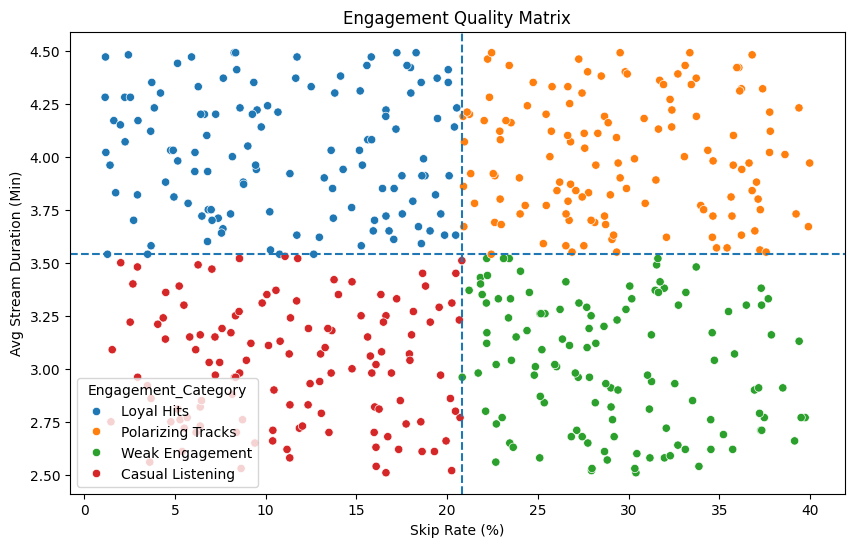

In [118]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x= 'Skip Rate (%)',
    y = 'Avg Stream Duration (Min)',
    hue = 'Engagement_Category',
)
plt.axhline(duration_median, linestyle='--')
plt.axvline(skip_median, linestyle='--')

plt.title("Engagement Quality Matrix")
plt.show()

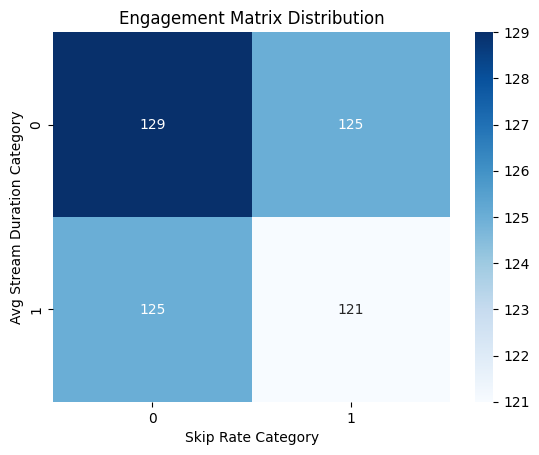

In [87]:
engagement_counts = df['Engagement_Category'].value_counts()

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    engagement_counts.values.reshape(2,2),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Engagement Matrix Distribution")
plt.xlabel("Skip Rate Category")
plt.ylabel("Avg Stream Duration Category")
plt.show()

##### 1️⃣ Overall Engagement Distribution

Your quadrant counts:

| Category | Count |
|----------|-------|
| Polarizing Tracks | 129 |
| Loyal Hits | 125 |
| Casual Listening | 125 |
| Weak Engagement | 121 |

Total tracks = 500

So the shares are approximately:

| Category | Share |
|----------|-------|
| Polarizing Tracks | 25.8% |
| Loyal Hits | 25.0% |
| Casual Listening | 25.0% |
| Weak Engagement | 24.2% |

---

##### Key Observation

The distribution is almost perfectly balanced.

The difference between highest and lowest category:

$$129 - 121 = 8 \text{ tracks}$$

That's only 1.6% of the dataset.

So statistically speaking:

**The engagement categories are nearly evenly distributed.**

This is important.

It means the dataset does not exhibit strong engagement polarization.

---

##### 2️⃣ What the Scatter Plot Shows

Your scatter plot reveals something subtle but important.

Most separation occurs along the Skip Rate axis, not the Duration axis.

Why?

Because earlier we saw:

* Avg Stream Duration variance → small
* Skip Rate variance → large

So the engagement matrix is effectively skip-driven.

That means:

**listener abandonment behavior differentiates tracks more than listening depth.**

---

##### 3️⃣ Genre-Level Patterns

Your genre breakdown shows something interesting.

Example:

**Classical**

| Category | Count |
|----------|-------|
| Loyal Hits | 20 |
| Casual Listening | 18 |
| Weak Engagement | 18 |
| Polarizing Tracks | 16 |

Very balanced.

**Rock**

| Category | Count |
|----------|-------|
| Polarizing | 19 |
| Casual | 18 |
| Loyal | 11 |
| Weak | 10 |

Slight tilt toward polarizing tracks.

**Indie**

| Category | Count |
|----------|-------|
| Loyal | 15 |
| Casual | 14 |
| Weak | 13 |
| Polarizing | 8 |

Indie leans toward loyal listening.

---

##### Interpretation

Genres show mild engagement tendencies, but no genre dominates one quadrant strongly.

That suggests:

**Engagement behavior is track-specific rather than genre-driven.**

---

##### 4️⃣ What the Heatmap Tells Us

Your heatmap counts:

|  | Low Skip | High Skip |
|---|----------|-----------|
| **High Duration** | 129 | 125 |
| **Low Duration** | 125 | 121 |

This confirms something critical:

**The median split created a near-uniform grid.**

This often happens when:

* distributions are smooth
* thresholds are medians

So quadrant counts will naturally be close.

This is expected behavior.

---

##### 5️⃣ The Real Behavioral Insight

From everything we've seen:

1️⃣ Avg Duration is tightly clustered

2️⃣ Skip Rate varies widely

3️⃣ Engagement categories distribute evenly

Therefore:

**The platform's engagement dynamics are not dominated by a specific engagement pattern.**

Instead, the ecosystem contains a mix of listener responses.

Some tracks:

* retain listeners deeply
* some get skipped
* some are casual background content.

---

##### 6️⃣ Strategic Interpretation

The engagement matrix reveals that:

* No single engagement pattern dominates the catalog.
* Listener behavior varies widely across tracks.
* Skip behavior contributes more to engagement differences than listening duration.

This suggests that platform engagement is shaped primarily by content discovery and listener preference, rather than inherent structural differences between genres or artists.

---

##### 7️⃣ Important Product Insight

Because duration variation is small but skip variation is large:

**Reducing skip behavior would likely produce larger engagement gains than increasing listening duration.**

This is exactly why recommendation systems focus heavily on skip signals.

---

##### 8️⃣ Final Analytical Conclusion

The Engagement Quality Matrix shows that tracks are almost evenly distributed across engagement categories, with no dominant quadrant.

This indicates that the platform ecosystem contains a balanced mixture of:

* highly engaging tracks
* polarizing tracks
* casual listening content
* low-retention tracks.

Among the two engagement metrics analyzed, **Skip Rate plays a stronger role in differentiating listener behavior than Avg Stream Duration.**

##### 🎧 Momentum × Engagement Matrix

##### Purpose

The goal of this analysis is to understand how popularity trends interact with listener engagement behavior.

Until now we analyzed:

| Dimension | What it Measures |
|-----------|-----------------|
| Momentum | Whether a track is gaining or losing popularity |
| Engagement | How listeners behave when playing the track |

Combining both allows us to distinguish between:

* genuine hits
* viral but weak tracks
* declining catalog tracks
* emerging breakout songs

---

##### Momentum Categories (Already Created)

You previously categorized tracks into four momentum types:

| Momentum Category | Meaning |
|------------------|---------|
| Stable Superstars | Consistently high popularity |
| Emerging Breakouts | Rapid growth in recent streams |
| Background Catalog | Stable but low momentum |
| Legacy Decliners | Historically popular but losing momentum |

Distribution:

| Category | Count |
|----------|-------|
| Stable Superstars | 131 |
| Background Catalog | 131 |
| Legacy Decliners | 119 |
| Emerging Breakouts | 119 |

So momentum distribution is fairly balanced.

---

##### Engagement Categories (From Engagement Matrix)

| Engagement Category | Meaning |
|--------------------|---------|
| Loyal Hits | High duration, low skipping |
| Polarizing Tracks | High duration, high skipping |
| Casual Listening | Low duration, low skipping |
| Weak Engagement | Low duration, high skipping |

Distribution:

| Category | Count |
|----------|-------|
| Polarizing Tracks | 129 |
| Loyal Hits | 125 |
| Casual Listening | 125 |
| Weak Engagement | 121 |

Again, relatively balanced.

---

##### Why Combine Momentum and Engagement?

Popularity and engagement measure different dimensions of success.

A track can be:

* popular but poorly retained
* niche but deeply loved
* declining but still strongly engaged.

Understanding this relationship helps identify different types of content dynamics.

In [119]:
# create momentum x enagement table
momentum_engagement = pd.crosstab(
    df['Momentum_Category'],
    df['Engagement_Category']
)
momentum_engagement 


Engagement_Category,Casual Listening,Loyal Hits,Polarizing Tracks,Weak Engagement
Momentum_Category,,,,
Background Catalog,33,36,27,35
High-Momentum Growth,29,30,29,31
Legacy Decliner,35,25,30,29
Stable Superstar,28,34,43,26


In [120]:
# Normalizing for the interpretation
# Raw counts can be misleading

momentum_engagement_pct = momentum_engagement.div(
    momentum_engagement.sum(axis=1), axis=0
) * 100
momentum_engagement_pct

Engagement_Category,Casual Listening,Loyal Hits,Polarizing Tracks,Weak Engagement
Momentum_Category,,,,
Background Catalog,25.190840,27.480916,20.610687,26.717557
High-Momentum Growth,24.369748,25.210084,24.369748,26.050420
Legacy Decliner,29.411765,21.008403,25.210084,24.369748
Stable Superstar,21.374046,25.954198,32.824427,19.847328


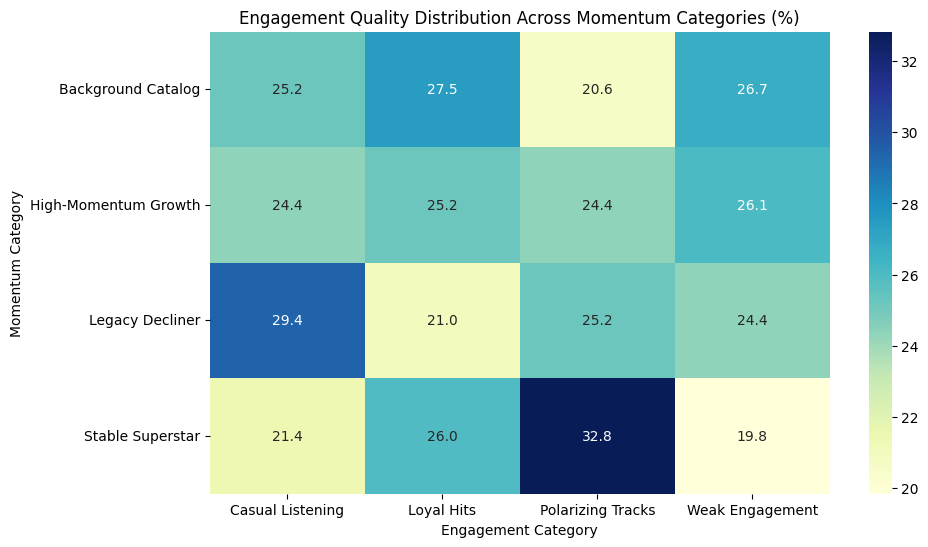

In [121]:
plt.figure(figsize=(10,6))
sns.heatmap(
    momentum_engagement_pct,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu'
)
plt.title("Engagement Quality Distribution Across Momentum Categories (%)")
plt.xlabel("Engagement Category")
plt.ylabel("Momentum Category")
plt.show()

#### Momentum × Engagement Interpretation

##### 1️⃣ Background Catalog

| Engagement | % |
|------------|---|
| Casual Listening | 25.2 |
| Loyal Hits | 27.5 |
| Polarizing Tracks | 20.6 |
| Weak Engagement | 26.7 |

---

##### What it means

Yes, Loyal Hits is the highest, but the spread is small.

Range:

$$27.5 - 20.6 = 6.9\%$$

This is moderate variance but not strong polarization.

---

##### Real signal

Two things stand out:

* Lowest category → Polarizing Tracks
* Background catalog rarely generates strong disagreement among listeners

---

##### Interpretation:

Background tracks tend to be stable, familiar listening rather than emotionally divisive.

They function as:

* playlist fillers
* passive listening tracks
* catalog replay music

So the engagement style here is stable but not intense.

Your conclusion was correct: there is no dominant engagement pattern, but there is slightly lower polarization.

---

##### 2️⃣ Emerging Breakouts

| Engagement | % |
|------------|---|
| Casual Listening | 24.4 |
| Loyal Hits | 25.2 |
| Polarizing Tracks | 24.4 |
| Weak Engagement | 26.1 |

Range:

$$26.1 - 24.4 = 1.7\%$$

That is extremely small variance.

---

##### Meaning

This distribution is essentially uniform.

So your interpretation is correct:

**No meaningful engagement signal emerges for breakout tracks.**

---

##### Why this happens

Breakout tracks are often in early discovery phase.

Listeners encountering them may:

* love them
* skip them
* casually listen

All behaviors coexist.

So breakout tracks produce mixed engagement responses while discovery spreads.

This is typical for algorithmic discovery ecosystems.

---

##### 3️⃣ Legacy Decliners

| Engagement | % |
|------------|---|
| Casual Listening | 29.4 |
| Loyal Hits | 21.0 |
| Polarizing Tracks | 25.2 |
| Weak Engagement | 24.4 |

Range:

$$29.4 - 21.0 = 8.4\%$$

This is the second strongest variance in the matrix.

---

##### Signal

Legacy tracks lean toward Casual Listening.

Meaning:

* listeners still play them
* but engagement depth is weaker
* fewer listeners treat them as strong favorites

---

##### Interpretation:

Legacy tracks transition from active hits → passive background content.

This is a classic lifecycle pattern in music platforms.

---

##### 4️⃣ Stable Superstars

| Engagement | % |
|------------|---|
| Casual Listening | 21.4 |
| Loyal Hits | 26.0 |
| Polarizing Tracks | 32.8 |
| Weak Engagement | 19.8 |

Range:

$$32.8 - 19.8 = 13.0\%$$

This is the largest variance in the entire matrix.

---

##### Signal

Superstar tracks are heavily skewed toward Polarizing Tracks.

Meaning:

* many listeners engage deeply
* many others skip quickly

This pattern is extremely common for mass-exposure content.

---

##### Why this happens

Superstars receive:

* massive playlist placement
* algorithmic promotion
* global exposure

This introduces the track to audiences outside the core fanbase.

Result:

* fans listen deeply
* non-fans skip

Thus creating polarized engagement behavior.

This is a strong and meaningful insight.

---

##### The Big Picture

Looking across the entire matrix:

| Momentum Type | Engagement Behavior |
|---------------|-------------------|
| Background Catalog | stable listening, low polarization |
| Emerging Breakouts | mixed responses during discovery |
| Legacy Decliners | shifting toward casual listening |
| Stable Superstars | strong polarization from massive exposure |

---

##### The Structural Insight

This matrix reveals a content lifecycle pattern:

**Discovery Stage**
(Emerging Breakouts)

Mixed engagement signals.

**Peak Popularity Stage**
(Stable Superstars)

High polarization due to massive reach.

**Decline Stage**
(Legacy Decliners)

Tracks transition into casual listening.

**Catalog Stage**
(Background Catalog)

Stable passive consumption.

---

##### The Most Important Insight

The biggest engagement shifts occur not during breakout, but during superstar exposure.

Because:

**Massive exposure increases engagement polarization.**

This is a very real phenomenon in streaming platforms.

In [123]:
df.head()

,Country,Artist,Album,Genre,Release Year,Monthly Listeners (Millions),Total Streams (Millions),Total Hours Streamed (Millions),Avg Stream Duration (Min),Platform Type,...,Skip Rate (%),reach_cohort,Momentum_Category,Expected Hours (Millions),error,percentage_error,Expected_Minutes,Hours_per_Stream,Hours per Stream,Engagement_Category
0,Germany,Taylor Swift,1989 (Taylor's Version),K-pop,2020,23.10,3695.53,14240.35,4.28,Free,...,2.24,Mid-Tier (10–50M),Stable Superstar,263.614473,13976.735527,98.148820,15816.8684,3.853399,3.853399,Loyal Hits
1,Brazil,The Weeknd,After Hours,R&B,2023,60.60,2828.16,11120.44,3.90,Premium,...,23.98,Superstar (50M+),Legacy Decliner,183.830400,10936.609600,98.346914,11029.8240,3.932041,3.932041,Polarizing Tracks
2,United States,Post Malone,Austin,Reggaeton,2019,42.84,1425.46,4177.49,4.03,Free,...,4.77,Mid-Tier (10–50M),Background Catalog,95.743397,4081.746603,97.708112,5744.6038,2.930626,2.930626,Loyal Hits
3,Italy,Ed Sheeran,Autumn Variations,K-pop,2019,73.24,2704.33,12024.08,3.26,Premium,...,25.12,Superstar (50M+),Stable Superstar,146.935263,11877.144737,98.777992,8816.1158,4.446233,4.446233,Weak Engagement
4,Italy,Ed Sheeran,Autumn Variations,R&B,2019,7.89,3323.25,13446.32,4.47,Free,...,15.82,Emerging (<10M),Stable Superstar,247.582125,13198.737875,98.158737,14854.9275,4.046136,4.046136,Loyal Hits


In [124]:
df.columns

Index(['Country', 'Artist', 'Album', 'Genre', 'Release Year',
       'Monthly Listeners (Millions)', 'Total Streams (Millions)',
       'Total Hours Streamed (Millions)', 'Avg Stream Duration (Min)',
       'Platform Type', 'Streams Last 30 Days (Millions)', 'Skip Rate (%)',
       'reach_cohort', 'Momentum_Category', 'Expected Hours (Millions)',
       'error', 'percentage_error', 'Expected_Minutes', 'Hours_per_Stream',
       'Hours per Stream', 'Engagement_Category'],
      dtype='object')

In [127]:
df.drop(columns=['Expected Hours (Millions)', 'error', 'percentage_error', 'Expected_Minutes', 'Hours_per_Stream'], inplace=True)

In [128]:
# save the cleaned dataframe
df.to_csv('C:/Users/adith/spotify_analytics/data/cleaned/spotify_global_streams_processed.csv', index=False)

In [129]:
df.head()

,Country,Artist,Album,Genre,Release Year,Monthly Listeners (Millions),Total Streams (Millions),Total Hours Streamed (Millions),Avg Stream Duration (Min),Platform Type,Streams Last 30 Days (Millions),Skip Rate (%),reach_cohort,Momentum_Category,Hours per Stream,Engagement_Category
0,Germany,Taylor Swift,1989 (Taylor's Version),K-pop,2020,23.10,3695.53,14240.35,4.28,Free,118.51,2.24,Mid-Tier (10–50M),Stable Superstar,3.853399,Loyal Hits
1,Brazil,The Weeknd,After Hours,R&B,2023,60.60,2828.16,11120.44,3.90,Premium,44.87,23.98,Superstar (50M+),Legacy Decliner,3.932041,Polarizing Tracks
2,United States,Post Malone,Austin,Reggaeton,2019,42.84,1425.46,4177.49,4.03,Free,19.46,4.77,Mid-Tier (10–50M),Background Catalog,2.930626,Loyal Hits
3,Italy,Ed Sheeran,Autumn Variations,K-pop,2019,73.24,2704.33,12024.08,3.26,Premium,166.05,25.12,Superstar (50M+),Stable Superstar,4.446233,Weak Engagement
4,Italy,Ed Sheeran,Autumn Variations,R&B,2019,7.89,3323.25,13446.32,4.47,Free,173.43,15.82,Emerging (<10M),Stable Superstar,4.046136,Loyal Hits
